# PHASE 1: LIBRARIES AND ENVIRONMENT SETUP

In [ ]:
pip install pmdarima

In [ ]:
# CORE DATA HANDLING
import numpy as np
import pandas as pd
# VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns
# STATISTICAL ANALYSIS
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# MACHINE LEARNING
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
# PREPROCESSING
from sklearn.preprocessing import StandardScaler
# DEEP LEARNING
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
# AUTOMATED ARIMA
import pmdarima as pm
# GENERAL SETTINGS
import warnings
warnings.filterwarnings("ignore")
# Set a fixed random seed where applicable.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
# DISPLAY ENVIRONMENT INFORMATION
print("PHASE 1: ENVIRONMENT CHECK")
print(f"Python/Pandas version : {pd.__version__}")
print(f"NumPy version         : {np.__version__}")
print(f"TensorFlow version    : {tf.__version__}")
print("\nRandom state:", RANDOM_STATE)

PHASE 1: ENVIRONMENT CHECK
Python/Pandas version : 2.2.3
NumPy version         : 2.1.3
TensorFlow version    : 2.20.0

Random state: 42


# Phase 2: Load and verify the datasets

In [ ]:
# Load Dunnhumby datasets
transaction = pd.read_csv("transaction_data.csv")
product = pd.read_csv("product.csv")
hh_demographic = pd.read_csv("hh_demographic.csv")
campaign_desc = pd.read_csv("campaign_desc.csv")
campaign_table = pd.read_csv("campaign_table.csv")
coupon = pd.read_csv("coupon.csv")
coupon_redempt = pd.read_csv("coupon_redempt.csv")
causal_data = pd.read_csv("causal_data.csv")

In [ ]:
# Check dataset dimensions
datasets = {
    "Transaction": transaction,
    "Product": product,
    "Household Demographic": hh_demographic,
    "Campaign Description": campaign_desc,
    "Campaign Table": campaign_table,
    "Coupon": coupon,
    "Coupon Redemption": coupon_redempt,
    "Causal Data": causal_data
}
dataset_summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})
dataset_summary

,Dataset,Rows,Columns
0,Transaction,2595732,12
1,Product,92353,7
2,Household Demographic,801,8
3,Campaign Description,30,4
4,Campaign Table,7208,3
5,Coupon,124548,3
6,Coupon Redemption,2318,4
7,Causal Data,36786524,5


In [ ]:
# Check data types and missing values
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.dtypes)
    print("Missing values:", df.isna().sum().sum())


Transaction
household_key          int64
BASKET_ID              int64
DAY                    int64
PRODUCT_ID             int64
QUANTITY               int64
SALES_VALUE          float64
STORE_ID               int64
RETAIL_DISC          float64
TRANS_TIME             int64
WEEK_NO                int64
COUPON_DISC          float64
COUPON_MATCH_DISC    float64
dtype: object
Missing values: 0

Product
PRODUCT_ID               int64
MANUFACTURER             int64
DEPARTMENT              object
BRAND                   object
COMMODITY_DESC          object
SUB_COMMODITY_DESC      object
CURR_SIZE_OF_PRODUCT    object
dtype: object
Missing values: 0

Household Demographic
AGE_DESC               object
MARITAL_STATUS_CODE    object
INCOME_DESC            object
HOMEOWNER_DESC         object
HH_COMP_DESC           object
HOUSEHOLD_SIZE_DESC    object
KID_CATEGORY_DESC      object
household_key           int64
dtype: object
Missing values: 0

Campaign Description
DESCRIPTION    object
CAMPAIGN  

In [ ]:
# Check duplicate rows
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

Transaction: 0 duplicate rows
Product: 0 duplicate rows
Household Demographic: 0 duplicate rows
Campaign Description: 0 duplicate rows
Campaign Table: 0 duplicate rows
Coupon: 5164 duplicate rows
Coupon Redemption: 0 duplicate rows
Causal Data: 0 duplicate rows


In [ ]:
# Check the transaction time range
print("Transaction days:", transaction["DAY"].min(), "to", transaction["DAY"].max())
print("Number of unique days:", transaction["DAY"].nunique())
print("Transaction weeks:", transaction["WEEK_NO"].min(), "to", transaction["WEEK_NO"].max())
print("Number of unique weeks:", transaction["WEEK_NO"].nunique())

Transaction days: 1 to 711
Number of unique days: 711
Transaction weeks: 1 to 102
Number of unique weeks: 102


In [ ]:
# Check key uniqueness
print("Unique households:", transaction["household_key"].nunique())
print("Unique products:", transaction["PRODUCT_ID"].nunique())
print("Unique stores:", transaction["STORE_ID"].nunique())
print("Unique baskets:", transaction["BASKET_ID"].nunique())
print("Products in product master:", product["PRODUCT_ID"].nunique())
print("Households in demographic data:", hh_demographic["household_key"].nunique())

Unique households: 2500
Unique products: 92339
Unique stores: 582
Unique baskets: 276484
Products in product master: 92353
Households in demographic data: 801


# PHASE 3: DATA QUALITY AND ANOMALY INVESTIGATION

In [ ]:
print("Transaction data:")
print("Rows:", len(transaction))
print("Sales <= 0:", (transaction["SALES_VALUE"] <= 0).sum())
print("Quantity <= 0:", (transaction["QUANTITY"] <= 0).sum())
print("Retail discount < 0:", (transaction["RETAIL_DISC"] < 0).sum())
print("Coupon discount < 0:", (transaction["COUPON_DISC"] < 0).sum())
print("Coupon match discount < 0:", (transaction["COUPON_MATCH_DISC"] < 0).sum())

Transaction data:
Rows: 2595732
Sales <= 0: 18850
Quantity <= 0: 14466
Retail discount < 0: 1303026
Coupon discount < 0: 36422
Coupon match discount < 0: 17449


In [ ]:
# Examine the distribution of the main transaction variables
transaction[
    ["QUANTITY", "SALES_VALUE", "RETAIL_DISC",
     "COUPON_DISC", "COUPON_MATCH_DISC"]
].describe()

,QUANTITY,SALES_VALUE,RETAIL_DISC,COUPON_DISC,COUPON_MATCH_DISC
count,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06,2.595732e+06
mean,1.004286e+02,3.104120e+00,-5.387054e-01,-1.641600e-02,-2.918564e-03
std,1.153436e+03,4.182274e+00,1.249191e+00,2.168410e-01,3.969004e-02
min,0.000000e+00,0.000000e+00,-1.800000e+02,-5.593000e+01,-7.700000e+00
25%,1.000000e+00,1.290000e+00,-6.900000e-01,0.000000e+00,0.000000e+00
50%,1.000000e+00,2.000000e+00,-1.000000e-02,0.000000e+00,0.000000e+00
75%,1.000000e+00,3.490000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,8.963800e+04,8.400000e+02,3.990000e+00,0.000000e+00,0.000000e+00


In [ ]:
# Identify the most extreme transaction values
print("Largest sales values:")
display(
    transaction.nlargest(10, "SALES_VALUE")[
        ["DAY", "PRODUCT_ID", "STORE_ID", "QUANTITY", "SALES_VALUE"]
    ]
)
print("\nLargest quantities:")
display(
    transaction.nlargest(10, "QUANTITY")[
        ["DAY", "PRODUCT_ID", "STORE_ID", "QUANTITY", "SALES_VALUE"]
    ]
)

Largest sales values:


,DAY,PRODUCT_ID,STORE_ID,QUANTITY,SALES_VALUE
1085442,339,12484608,412,3,840.00
2030766,574,948670,415,5,631.80
655985,230,1089093,323,2,505.00
1152895,355,13212959,361,1,499.99
547657,201,1089093,323,1,455.00
526495,196,1089093,343,1,430.00
3600,10,1089093,372,1,400.00
2352647,654,1089093,31782,1,380.00
1366400,408,13506935,356,1,329.99
807063,269,9296877,329,25,324.75



Largest quantities:


,DAY,PRODUCT_ID,STORE_ID,QUANTITY,SALES_VALUE
1750942,503,6534178,384,89638,250.00
468356,181,6544236,375,85055,210.00
481876,185,6534178,384,61335,150.21
166536,103,6534178,327,51912,110.00
1340882,402,6534178,310,48073,121.10
2472791,682,6534178,433,45475,100.00
1560340,456,6534178,327,41833,115.00
376686,158,6534178,327,41686,100.00
156049,99,6544236,327,41485,85.00
87625,74,6534178,329,39365,72.00


In [ ]:
# Investigate the relationship between zero sales and zero quantity
zero_sales = transaction["SALES_VALUE"] == 0
zero_quantity = transaction["QUANTITY"] == 0
print("Zero sales and zero quantity:",
      (zero_sales & zero_quantity).sum())

print("Zero sales with positive quantity:",
      (zero_sales & (transaction["QUANTITY"] > 0)).sum())

print("Positive sales with zero quantity:",
      ((transaction["SALES_VALUE"] > 0) & zero_quantity).sum())

Zero sales and zero quantity: 14399
Zero sales with positive quantity: 4451
Positive sales with zero quantity: 67


In [ ]:
# Examine high-quantity transactions
quantity_thresholds = [10, 50, 100, 500, 1000, 5000]
for threshold in quantity_thresholds:
    count = (transaction["QUANTITY"] > threshold).sum()
    percentage = count / len(transaction) * 100
    print(f"Quantity > {threshold}: {count:,} rows ({percentage:.3f}%)")

Quantity > 10: 25,406 rows (0.979%)
Quantity > 50: 23,156 rows (0.892%)
Quantity > 100: 23,136 rows (0.891%)
Quantity > 500: 23,126 rows (0.891%)
Quantity > 1000: 23,101 rows (0.890%)
Quantity > 5000: 20,205 rows (0.778%)


In [ ]:
# Examine high-value transactions
sales_thresholds = [50, 100, 200, 500]
for threshold in sales_thresholds:
    count = (transaction["SALES_VALUE"] > threshold).sum()
    percentage = count / len(transaction) * 100
    print(f"Sales > {threshold}: {count:,} rows ({percentage:.3f}%)")

Sales > 50: 1,595 rows (0.061%)
Sales > 100: 133 rows (0.005%)
Sales > 200: 31 rows (0.001%)
Sales > 500: 3 rows (0.000%)


In [ ]:
# Check whether extreme quantities are concentrated in particular products/stores
extreme_quantity = transaction[transaction["QUANTITY"] > 1000]
print("Extreme quantity rows:", len(extreme_quantity))
print("Unique products:", extreme_quantity["PRODUCT_ID"].nunique())
print("Unique stores:", extreme_quantity["STORE_ID"].nunique())
display(
    extreme_quantity[
        ["DAY", "PRODUCT_ID", "STORE_ID", "QUANTITY", "SALES_VALUE",
         "RETAIL_DISC", "COUPON_DISC"]
    ].head(20)
)

Extreme quantity rows: 23101
Unique products: 27
Unique stores: 164


,DAY,PRODUCT_ID,STORE_ID,QUANTITY,SALES_VALUE,RETAIL_DISC,COUPON_DISC
5380,12,6534178,422,1461,3.20,-0.01,0.0
6213,13,6534178,310,2416,5.00,-0.24,0.0
6674,14,6534178,422,2728,6.00,-0.27,0.0
7198,15,6534178,310,8737,20.00,-0.01,0.0
8055,17,6534178,408,11066,23.01,-1.10,0.0
8866,18,6534178,408,5598,12.20,-0.01,0.0
9201,18,6534178,341,9026,20.03,0.00,0.0
10264,19,6534178,310,12025,25.00,-1.20,0.0
10508,20,6534178,408,9255,20.07,-0.01,0.0
10950,20,397896,3217,11266,25.00,-0.34,0.0


In [ ]:
# Investigate duplicate coupon records
coupon_duplicates = coupon[coupon.duplicated(keep=False)].sort_values(
    ["COUPON_UPC", "PRODUCT_ID", "CAMPAIGN"]
)
print("Duplicate coupon rows:", coupon_duplicates.shape[0])
display(coupon_duplicates.head(20))

Duplicate coupon rows: 6988


,COUPON_UPC,PRODUCT_ID,CAMPAIGN
73199,10000085426,930799,13
73748,10000085426,930799,13
62387,10000085427,983002,13
64785,10000085427,983002,13
64507,10000085427,1078612,13
64908,10000085427,1078612,13
64913,10000085427,13072690,13
64933,10000085427,13072690,13
59992,10000085427,13911346,13
64343,10000085427,13911346,13


In [ ]:
# Check whether coupon duplicates are exact duplicates
# or represent different product/campaign relationships
print(
    "Unique duplicated coupon combinations:",
    coupon_duplicates[
        ["COUPON_UPC", "PRODUCT_ID", "CAMPAIGN"]
    ].drop_duplicates().shape[0]
)

Unique duplicated coupon combinations: 1824


In [ ]:
# Examine the structure of causal data
print("Causal data rows:", len(causal_data))
print("Unique products:", causal_data["PRODUCT_ID"].nunique())
print("Unique stores:", causal_data["STORE_ID"].nunique())
print("Unique weeks:", causal_data["WEEK_NO"].nunique())
print("\nDisplay values:")
print(causal_data["display"].value_counts(dropna=False))
print("\nMailer values:")
print(causal_data["mailer"].value_counts(dropna=False))

Causal data rows: 36786524
Unique products: 68377
Unique stores: 115
Unique weeks: 93

Display values:
display
0    21038745
9     2699467
5     2575289
7     2362118
3     2073738
6     1816021
2     1812840
1     1102141
A      713180
4      592985
Name: count, dtype: int64

Mailer values:
mailer
A    17106789
0    11534183
D     4467453
H     1560395
F     1077549
J      306924
L      301327
C      291059
X      120823
Z       19453
P         569
Name: count, dtype: int64


In [ ]:
# Check whether PRODUCT_ID + STORE_ID + WEEK_NO uniquely identifies
# a causal observation
causal_key_duplicates = causal_data.duplicated(
    subset=["PRODUCT_ID", "STORE_ID", "WEEK_NO"]
).sum()
print(
    "Duplicate PRODUCT_ID + STORE_ID + WEEK_NO combinations:",
    causal_key_duplicates
)

Duplicate PRODUCT_ID + STORE_ID + WEEK_NO combinations: 15245


In [ ]:
# Examine duplicated causal keys and their promotional combinations
causal_duplicates = causal_data[
    causal_data.duplicated(
        subset=["PRODUCT_ID", "STORE_ID", "WEEK_NO"],
        keep=False
    )
].sort_values(
    ["PRODUCT_ID", "STORE_ID", "WEEK_NO"]
)

print("Rows involved in duplicate causal keys:", len(causal_duplicates))
display(
    causal_duplicates.head(30)
)

Rows involved in duplicate causal keys: 30490


,PRODUCT_ID,STORE_ID,WEEK_NO,display,mailer
45594,27658,361,59,0,D
45595,27658,361,59,6,D
45604,27658,361,76,0,D
45605,27658,361,76,6,D
49368,27658,34280,89,0,D
49369,27658,34280,89,6,D
49371,27658,34280,91,0,D
49372,27658,34280,91,6,D
49373,27658,34280,92,0,D
49374,27658,34280,92,6,D


In [ ]:
# Check whether duplicate causal keys contain different display/mailer values
duplicate_promo_combinations = (
    causal_duplicates
    .groupby(["PRODUCT_ID", "STORE_ID", "WEEK_NO"])
    [["display", "mailer"]]
    .nunique()
    .reset_index()
)
print(
    "Duplicate keys with more than one display value:",
    (duplicate_promo_combinations["display"] > 1).sum()
)
print(
    "Duplicate keys with more than one mailer value:",
    (duplicate_promo_combinations["mailer"] > 1).sum()
)
display(duplicate_promo_combinations.head(20))

Duplicate keys with more than one display value: 15208
Duplicate keys with more than one mailer value: 105


,PRODUCT_ID,STORE_ID,WEEK_NO,display,mailer
0,27658,361,59,2,1
1,27658,361,76,2,1
2,27658,34280,89,2,1
3,27658,34280,91,2,1
4,27658,34280,92,2,1
5,27658,34280,93,2,1
6,27658,34280,94,2,1
7,27658,34280,95,2,1
8,27658,34280,98,2,1
9,28897,361,50,2,1


In [ ]:
# Check whether duplicate causal rows are exact duplicates
exact_causal_duplicates = causal_data.duplicated(
    subset=["PRODUCT_ID", "STORE_ID", "WEEK_NO", "display", "mailer"]
).sum()
print(
    "Exact duplicate causal rows:",
    exact_causal_duplicates
)

Exact duplicate causal rows: 0


In [ ]:
# Check whether transaction days form a continuous sequence
transaction_days = np.sort(transaction["DAY"].unique())
expected_days = np.arange(
    transaction_days.min(),
    transaction_days.max() + 1
)
missing_days = np.setdiff1d(
    expected_days,
    transaction_days
)
print("Minimum DAY:", transaction_days.min())
print("Maximum DAY:", transaction_days.max())
print("Unique transaction days:", len(transaction_days))
print("Missing days:", len(missing_days))
if len(missing_days) > 0:
    print("Missing DAY values:", missing_days[:20])

Minimum DAY: 1
Maximum DAY: 711
Unique transaction days: 711
Missing days: 0


In [ ]:
# Examine the relationship between DAY and WEEK_NO
day_week_check = (
    transaction
    .groupby("WEEK_NO")["DAY"]
    .agg(["min", "max", "nunique"])
    .reset_index()
)

display(day_week_check.head(15))
display(day_week_check.tail(15))

,WEEK_NO,min,max,nunique
0,1,1,5,5
1,2,6,12,7
2,3,13,19,7
3,4,20,26,7
4,5,27,33,7
5,6,34,40,7
6,7,41,47,7
7,8,48,54,7
8,9,55,61,7
9,10,62,68,7


,WEEK_NO,min,max,nunique
87,88,608,614,7
88,89,615,621,7
89,90,622,628,7
90,91,629,635,7
91,92,636,642,7
92,93,643,649,7
93,94,650,656,7
94,95,657,663,7
95,96,664,670,7
96,97,671,677,7


In [ ]:
# Each day should correspond to a single week number
day_week_counts = (
    transaction
    .groupby("DAY")["WEEK_NO"]
    .nunique()
)
print(
    "Days associated with more than one WEEK_NO:",
    (day_week_counts > 1).sum()
)
print(
    "Maximum WEEK_NO values associated with one day:",
    day_week_counts.max()
)

Days associated with more than one WEEK_NO: 0
Maximum WEEK_NO values associated with one day: 1


In [ ]:
# Compare temporal coverage across the main transaction and causal datasets
print("Transaction DAY range:",
      transaction["DAY"].min(),
      "to",
      transaction["DAY"].max())

print("Transaction WEEK_NO range:",
      transaction["WEEK_NO"].min(),
      "to",
      transaction["WEEK_NO"].max())

print("Causal WEEK_NO range:",
      causal_data["WEEK_NO"].min(),
      "to",
      causal_data["WEEK_NO"].max())

print("Transaction unique weeks:",
      transaction["WEEK_NO"].nunique())

print("Causal unique weeks:",
      causal_data["WEEK_NO"].nunique())

Transaction DAY range: 1 to 711
Transaction WEEK_NO range: 1 to 102
Causal WEEK_NO range: 9 to 101
Transaction unique weeks: 102
Causal unique weeks: 93


In [ ]:
# Identify which transaction weeks are not represented in causal data
transaction_weeks = set(transaction["WEEK_NO"].unique())
causal_weeks = set(causal_data["WEEK_NO"].unique())

missing_causal_weeks = sorted(
    transaction_weeks - causal_weeks
)
print(
    "Transaction weeks without causal data:",
    len(missing_causal_weeks)
)
print(
    "Missing causal weeks:",
    missing_causal_weeks
)

Transaction weeks without causal data: 9
Missing causal weeks: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(102)]


In [ ]:
# Create a temporary daily sales summary for quality checking
daily_check = (
    transaction
    .groupby("DAY")
    .agg(
        DAILY_SALES=("SALES_VALUE", "sum"),
        DAILY_QUANTITY=("QUANTITY", "sum"),
        TRANSACTIONS=("PRODUCT_ID", "size"),
        BASKETS=("BASKET_ID", "nunique"),
        ACTIVE_HOUSEHOLDS=("household_key", "nunique"),
        ACTIVE_PRODUCTS=("PRODUCT_ID", "nunique"),
        ACTIVE_STORES=("STORE_ID", "nunique")
    )
    .reset_index()
)

print("Daily observations:", len(daily_check))
print("\nMissing daily sales:", daily_check["DAILY_SALES"].isna().sum())
print("Days with zero sales:", (daily_check["DAILY_SALES"] == 0).sum())

display(daily_check.head())
display(daily_check.describe())

Daily observations: 711

Missing daily sales: 0
Days with zero sales: 0


,DAY,DAILY_SALES,DAILY_QUANTITY,TRANSACTIONS,BASKETS,ACTIVE_HOUSEHOLDS,ACTIVE_PRODUCTS,ACTIVE_STORES
0,1,549.31,302,238,16,15,226,15
1,2,458.91,156,137,13,12,132,10
2,3,1560.37,678,524,44,33,471,30
3,4,1785.64,849,675,44,36,615,30
4,5,856.93,368,307,25,23,291,21


,DAY,DAILY_SALES,DAILY_QUANTITY,TRANSACTIONS,BASKETS,ACTIVE_HOUSEHOLDS,ACTIVE_PRODUCTS,ACTIVE_STORES
count,711.000000,711.000000,711.000000,711.000000,711.000000,711.000000,711.000000,711.000000
mean,356.000000,11332.578172,366646.444444,3650.818565,388.866385,317.205345,2599.119550,100.659634
std,205.392308,3729.869251,144359.301898,1190.657509,106.966418,85.901991,741.596681,16.675428
min,1.000000,2.990000,2.000000,2.000000,1.000000,1.000000,2.000000,1.000000
25%,178.500000,9877.355000,313133.000000,3167.500000,376.000000,311.000000,2345.500000,102.000000
50%,356.000000,11519.370000,387553.000000,3713.000000,408.000000,335.000000,2668.000000,105.000000
75%,533.500000,13494.215000,457838.500000,4324.500000,448.500000,363.000000,3036.000000,108.000000
max,711.000000,24760.100000,754728.000000,7493.000000,668.000000,521.000000,4708.000000,117.000000


In [ ]:
# Identify the highest and lowest sales days
print("Highest-sales days:")
display(
    daily_check
    .nlargest(10, "DAILY_SALES")
)

print("\nLowest-sales days:")
display(
    daily_check
    .nsmallest(10, "DAILY_SALES")
)

Highest-sales days:


,DAY,DAILY_SALES,DAILY_QUANTITY,TRANSACTIONS,BASKETS,ACTIVE_HOUSEHOLDS,ACTIVE_PRODUCTS,ACTIVE_STORES
640,641,24760.10,529887,7066,628,489,4427,111
691,692,23511.82,550704,7493,582,487,4708,108
275,276,23018.88,512881,6715,582,466,4296,113
690,691,22599.18,481358,7426,516,428,4634,108
245,246,20901.13,485665,6746,668,521,3853,115
683,684,20335.99,394960,6681,543,450,4249,110
609,610,20144.70,525351,6352,643,507,3716,113
620,621,19612.10,434622,6551,488,400,4329,113
668,669,19105.24,444394,6260,522,428,4019,109
639,640,19095.37,557822,5355,480,398,3650,106



Lowest-sales days:


,DAY,DAILY_SALES,DAILY_QUANTITY,TRANSACTIONS,BASKETS,ACTIVE_HOUSEHOLDS,ACTIVE_PRODUCTS,ACTIVE_STORES
642,643,2.99,2,2,1,1,2,1
277,278,22.49,6,6,1,1,6,1
1,2,458.91,156,137,13,12,132,10
0,1,549.31,302,238,16,15,226,15
4,5,856.93,368,307,25,23,291,21
5,6,1008.15,428,338,37,28,316,22
8,9,1050.95,465,362,39,31,343,29
7,8,1203.85,604,434,43,34,392,29
6,7,1271.29,558,465,34,27,439,22
14,15,1371.23,9373,494,62,43,448,33


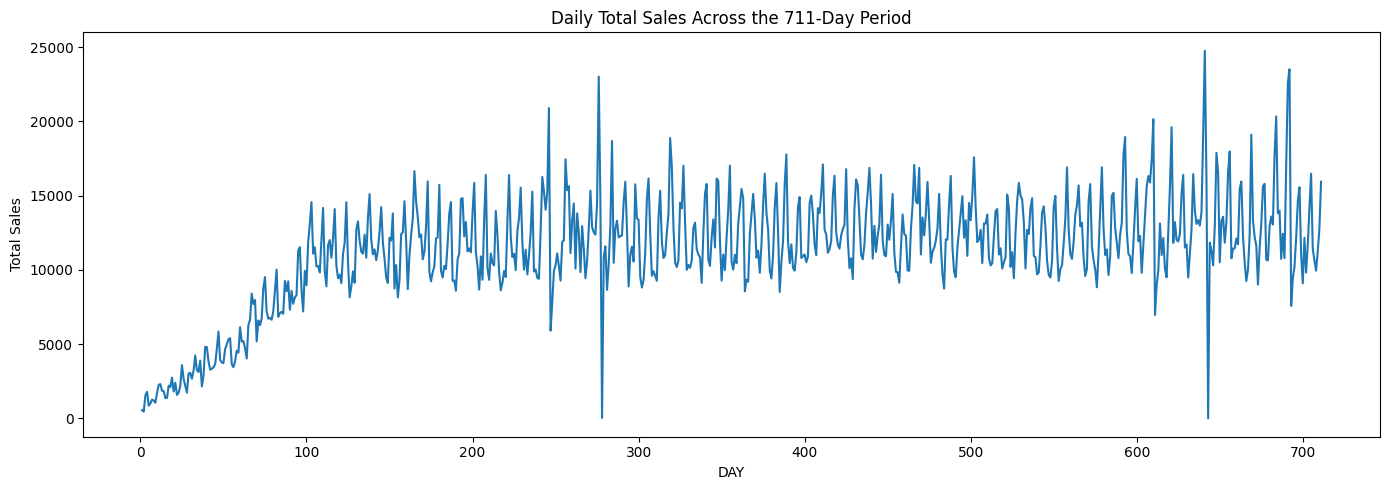

In [ ]:
# Visual inspection of the daily sales series
plt.figure(figsize=(14, 5))
plt.plot(
    daily_check["DAY"],
    daily_check["DAILY_SALES"]
)
plt.title("Daily Total Sales Across the 711-Day Period")
plt.xlabel("DAY")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

In [ ]:
# Investigate the two extreme low-activity days
anomaly_days = [278, 643]

anomaly_summary = (
    daily_check[
        daily_check["DAY"].isin(anomaly_days)
    ]
)
display(anomaly_summary)

,DAY,DAILY_SALES,DAILY_QUANTITY,TRANSACTIONS,BASKETS,ACTIVE_HOUSEHOLDS,ACTIVE_PRODUCTS,ACTIVE_STORES
277,278,22.49,6,6,1,1,6,1
642,643,2.99,2,2,1,1,2,1


In [ ]:
# Examine the transaction records for the two unusually sparse days
for day in anomaly_days:
    day_data = transaction[
        transaction["DAY"] == day
    ]
    print("\nDAY:", day)
    print("Rows:", len(day_data))
    print("Households:", day_data["household_key"].nunique())
    print("Baskets:", day_data["BASKET_ID"].nunique())
    print("Products:", day_data["PRODUCT_ID"].nunique())
    print("Stores:", day_data["STORE_ID"].nunique())
    display(
        day_data[
            [
                "household_key",
                "BASKET_ID",
                "DAY",
                "PRODUCT_ID",
                "QUANTITY",
                "SALES_VALUE",
                "STORE_ID",
                "WEEK_NO"
            ]
        ]
    )


DAY: 278
Rows: 6
Households: 1
Baskets: 1
Products: 6
Stores: 1


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,WEEK_NO
844174,1393,31126387287,278,3692358,1,5.59,2734,40
844175,1393,31126387287,278,3773679,1,3.17,2734,40
844176,1393,31126387287,278,3841423,1,3.69,2734,40
844177,1393,31126387287,278,3894307,1,2.19,2734,40
844178,1393,31126387287,278,3938042,1,1.98,2734,40
844179,1393,31126387287,278,6658823,1,5.87,2734,40



DAY: 643
Rows: 2
Households: 1
Baskets: 1
Products: 2
Stores: 1


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,WEEK_NO
2312119,1795,41400285005,643,1104475,1,2.00,31782,93
2312120,1795,41400285005,643,17168855,1,0.99,31782,93


In [ ]:
# Compare activity immediately before and after each anomalous day
for day in anomaly_days:
    comparison = daily_check[
        daily_check["DAY"].between(day - 3, day + 3)
    ]

    print("\nActivity around DAY", day)
    display(comparison)


Activity around DAY 278


,DAY,DAILY_SALES,DAILY_QUANTITY,TRANSACTIONS,BASKETS,ACTIVE_HOUSEHOLDS,ACTIVE_PRODUCTS,ACTIVE_STORES
274,275,14520.57,293889,4425,424,348,3085,102
275,276,23018.88,512881,6715,582,466,4296,113
276,277,14635.13,301878,4160,497,402,2811,113
277,278,22.49,6,6,1,1,6,1
278,279,10859.11,395343,3188,409,328,2328,105
279,280,11583.51,371777,3814,410,339,2745,107
280,281,8657.83,329897,2940,370,315,2148,102



Activity around DAY 643


,DAY,DAILY_SALES,DAILY_QUANTITY,TRANSACTIONS,BASKETS,ACTIVE_HOUSEHOLDS,ACTIVE_PRODUCTS,ACTIVE_STORES
639,640,19095.37,557822,5355,480,398,3650,106
640,641,24760.10,529887,7066,628,489,4427,111
641,642,16005.20,238480,4558,513,423,3053,113
642,643,2.99,2,2,1,1,2,1
643,644,11830.28,361352,3845,377,312,2813,102
644,645,11304.24,396328,3446,395,323,2536,105
645,646,10303.79,192741,3286,348,276,2485,100


In [ ]:
# Check the week numbers and temporal position of the two anomalous days
print(
    daily_check[
        daily_check["DAY"].isin(anomaly_days)
    ][
        ["DAY", "DAILY_SALES", "TRANSACTIONS", "BASKETS",
         "ACTIVE_HOUSEHOLDS", "ACTIVE_PRODUCTS", "ACTIVE_STORES"]
    ]
)

print("\nWeek number for each anomalous day:")

display(
    transaction[
        transaction["DAY"].isin(anomaly_days)
    ][
        ["DAY", "WEEK_NO"]
    ].drop_duplicates()
)

     DAY  DAILY_SALES  TRANSACTIONS  BASKETS  ACTIVE_HOUSEHOLDS  \
277  278        22.49             6        1                  1   
642  643         2.99             2        1                  1   

     ACTIVE_PRODUCTS  ACTIVE_STORES  
277                6              1  
642                2              1  

Week number for each anomalous day:


,DAY,WEEK_NO
844174,278,40
2312119,643,93


In [ ]:
# Identify whether the two coverage anomalies are extreme across daily features
features_to_check = [
    "DAILY_SALES",
    "DAILY_QUANTITY",
    "TRANSACTIONS",
    "BASKETS",
    "ACTIVE_HOUSEHOLDS",
    "ACTIVE_PRODUCTS",
    "ACTIVE_STORES"
]

for feature in features_to_check:
    q1 = daily_check[feature].quantile(0.25)
    q3 = daily_check[feature].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    anomaly_count = (
        (daily_check[feature] < lower_bound) |
        (daily_check[feature] > upper_bound)
    ).sum()

    print(
        feature,
        "-> IQR-based extreme days:",
        anomaly_count
    )

DAILY_SALES -> IQR-based extreme days: 64
DAILY_QUANTITY -> IQR-based extreme days: 62
TRANSACTIONS -> IQR-based extreme days: 62
BASKETS -> IQR-based extreme days: 85
ACTIVE_HOUSEHOLDS -> IQR-based extreme days: 91
ACTIVE_PRODUCTS -> IQR-based extreme days: 65
ACTIVE_STORES -> IQR-based extreme days: 74


In [ ]:
# Flag days with identified incomplete transaction coverage
daily_check["DATA_COVERAGE_ANOMALY"] = (
    daily_check["DAY"].isin([278, 643])
).astype(int)
print(
    "Flagged coverage-anomaly days:",
    daily_check["DATA_COVERAGE_ANOMALY"].sum()
)
display(
    daily_check[
        daily_check["DATA_COVERAGE_ANOMALY"] == 1
    ]
)

Flagged coverage-anomaly days: 2


,DAY,DAILY_SALES,DAILY_QUANTITY,TRANSACTIONS,BASKETS,ACTIVE_HOUSEHOLDS,ACTIVE_PRODUCTS,ACTIVE_STORES,DATA_COVERAGE_ANOMALY
277,278,22.49,6,6,1,1,6,1,1
642,643,2.99,2,2,1,1,2,1,1


# Phase 4: Exploratory Time-Series Analysis

In [ ]:
# Create the initial daily modelling dataset
daily_model = (
    transaction
    .groupby("DAY")
    .agg(
        DAILY_SALES=("SALES_VALUE", "sum"),
        DAILY_QUANTITY=("QUANTITY", "sum"),
        TRANSACTIONS=("PRODUCT_ID", "size"),
        BASKETS=("BASKET_ID", "nunique"),
        ACTIVE_HOUSEHOLDS=("household_key", "nunique"),
        ACTIVE_PRODUCTS=("PRODUCT_ID", "nunique"),
        ACTIVE_STORES=("STORE_ID", "nunique"),
        RETAIL_DISCOUNT=("RETAIL_DISC", "sum"),
        COUPON_DISCOUNT=("COUPON_DISC", "sum"),
        COUPON_MATCH_DISCOUNT=("COUPON_MATCH_DISC", "sum")
    )
    .reset_index()
)
daily_model["DATA_COVERAGE_ANOMALY"] = (
    daily_model["DAY"].isin([278, 643])
).astype(int)
print("Daily modelling observations:", len(daily_model))
print("Daily modelling columns:", daily_model.shape[1])
display(daily_model.head())

Daily modelling observations: 711
Daily modelling columns: 12


,DAY,DAILY_SALES,DAILY_QUANTITY,TRANSACTIONS,BASKETS,ACTIVE_HOUSEHOLDS,ACTIVE_PRODUCTS,ACTIVE_STORES,RETAIL_DISCOUNT,COUPON_DISCOUNT,COUPON_MATCH_DISCOUNT,DATA_COVERAGE_ANOMALY
0,1,549.31,302,238,16,15,226,15,-137.54,-9.29,-1.10,0
1,2,458.91,156,137,13,12,132,10,-95.08,-3.55,-0.45,0
2,3,1560.37,678,524,44,33,471,30,-293.35,-2.80,-1.20,0
3,4,1785.64,849,675,44,36,615,30,-355.88,-1.10,0.00,0
4,5,856.93,368,307,25,23,291,21,-155.40,0.00,0.00,0


In [ ]:
# Verify the daily modelling dataset
print("Missing values:")
display(daily_model.isna().sum())
print("\nDuplicate DAY values:",
      daily_model["DAY"].duplicated().sum())
print("\nDAY range:",
      daily_model["DAY"].min(),
      "to",
      daily_model["DAY"].max())
print("\nCoverage anomalies:",
      daily_model["DATA_COVERAGE_ANOMALY"].sum())

Missing values:


,0
DAY,0
DAILY_SALES,0
DAILY_QUANTITY,0
TRANSACTIONS,0
BASKETS,0
ACTIVE_HOUSEHOLDS,0
ACTIVE_PRODUCTS,0
ACTIVE_STORES,0
RETAIL_DISCOUNT,0
COUPON_DISCOUNT,0



Duplicate DAY values: 0

DAY range: 1 to 711

Coverage anomalies: 2


In [ ]:
# Add the transaction week number to the daily modelling dataset
day_week_mapping = (
    transaction[["DAY", "WEEK_NO"]]
    .drop_duplicates()
)

daily_model = daily_model.merge(
    day_week_mapping,
    on="DAY",
    how="left",
    validate="one_to_one"
)

print("Missing WEEK_NO values:", daily_model["WEEK_NO"].isna().sum())
print("Unique weeks:", daily_model["WEEK_NO"].nunique())

display(daily_model.head())

Missing WEEK_NO values: 0
Unique weeks: 102


,DAY,DAILY_SALES,DAILY_QUANTITY,TRANSACTIONS,BASKETS,ACTIVE_HOUSEHOLDS,ACTIVE_PRODUCTS,ACTIVE_STORES,RETAIL_DISCOUNT,COUPON_DISCOUNT,COUPON_MATCH_DISCOUNT,DATA_COVERAGE_ANOMALY,WEEK_NO
0,1,549.31,302,238,16,15,226,15,-137.54,-9.29,-1.10,0,1
1,2,458.91,156,137,13,12,132,10,-95.08,-3.55,-0.45,0,1
2,3,1560.37,678,524,44,33,471,30,-293.35,-2.80,-1.20,0,1
3,4,1785.64,849,675,44,36,615,30,-355.88,-1.10,0.00,0,1
4,5,856.93,368,307,25,23,291,21,-155.40,0.00,0.00,0,1


In [ ]:
# Verify the daily dataset after adding WEEK_NO
print("Daily observations:", len(daily_model))
print("Duplicate DAY values:", daily_model["DAY"].duplicated().sum())
print(
    "WEEK_NO range:",
    daily_model["WEEK_NO"].min(),
    "to",
    daily_model["WEEK_NO"].max()
)

Daily observations: 711
Duplicate DAY values: 0
WEEK_NO range: 1 to 102


In [ ]:
# Calculate rolling averages of daily sales
daily_model["SALES_ROLLING_7"] = (
    daily_model["DAILY_SALES"]
    .rolling(window=7, min_periods=1)
    .mean()
)
daily_model["SALES_ROLLING_28"] = (
    daily_model["DAILY_SALES"]
    .rolling(window=28, min_periods=1)
    .mean()
)
display(
    daily_model[
        [
            "DAY",
            "DAILY_SALES",
            "SALES_ROLLING_7",
            "SALES_ROLLING_28"
        ]
    ].head(35)
)

,DAY,DAILY_SALES,SALES_ROLLING_7,SALES_ROLLING_28
0,1,549.31,549.310000,549.310000
1,2,458.91,504.110000,504.110000
2,3,1560.37,856.196667,856.196667
3,4,1785.64,1088.557500,1088.557500
4,5,856.93,1042.232000,1042.232000
5,6,1008.15,1036.551667,1036.551667
6,7,1271.29,1070.085714,1070.085714
7,8,1203.85,1163.591429,1086.806250
8,9,1050.95,1248.168571,1082.822222
9,10,1714.38,1270.170000,1145.978000


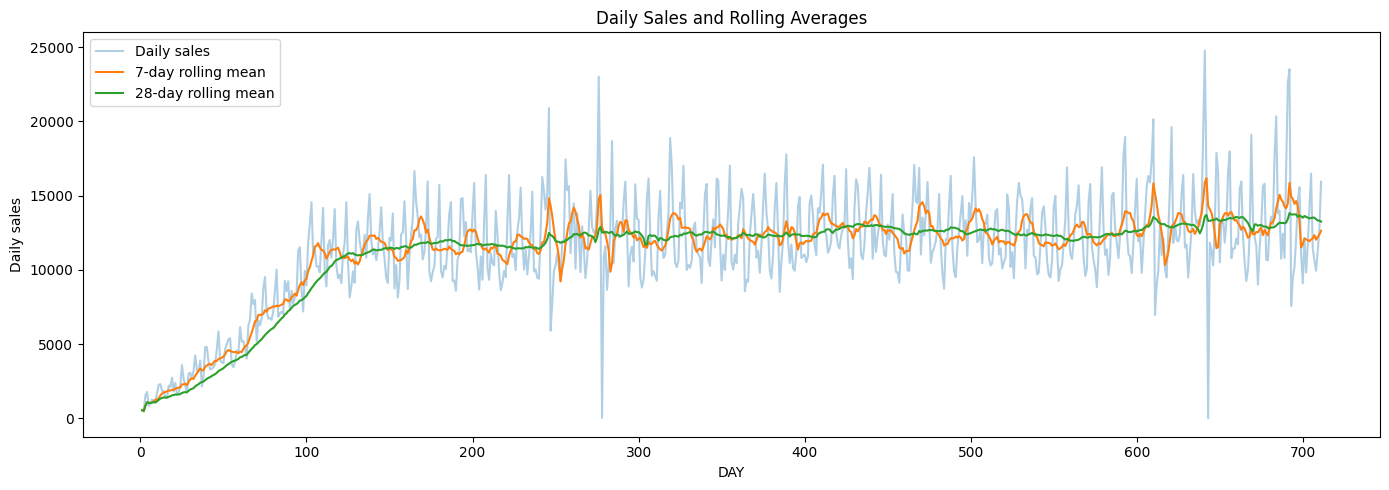

In [ ]:
# Examine the underlying sales trend
plt.figure(figsize=(14, 5))
plt.plot(
    daily_model["DAY"],
    daily_model["DAILY_SALES"],
    alpha=0.35,
    label="Daily sales"
)
plt.plot(
    daily_model["DAY"],
    daily_model["SALES_ROLLING_7"],
    label="7-day rolling mean"
)
plt.plot(
    daily_model["DAY"],
    daily_model["SALES_ROLLING_28"],
    label="28-day rolling mean"
)
plt.xlabel("DAY")
plt.ylabel("Daily sales")
plt.title("Daily Sales and Rolling Averages")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Summarise sales by transaction week
weekly_sales = (
    daily_model
    .groupby("WEEK_NO")
    .agg(
        WEEKLY_SALES=("DAILY_SALES", "sum"),
        AVERAGE_DAILY_SALES=("DAILY_SALES", "mean"),
        DAYS_RECORDED=("DAY", "count")
    )
    .reset_index()
)

display(weekly_sales.head(10))
display(weekly_sales.tail(10))

,WEEK_NO,WEEKLY_SALES,AVERAGE_DAILY_SALES,DAYS_RECORDED
0,1,5211.16,1042.232000,5
1,2,10821.35,1545.907143,7
2,3,13498.20,1928.314286,7
3,4,15965.99,2280.855714,7
4,5,20139.82,2877.117143,7
5,6,24923.90,3560.557143,7
6,7,28073.97,4010.567143,7
7,8,31793.77,4541.967143,7
8,9,31244.17,4463.452857,7
9,10,42994.38,6142.054286,7


,WEEK_NO,WEEKLY_SALES,AVERAGE_DAILY_SALES,DAYS_RECORDED
92,93,80832.16,11547.451429,7
93,94,96964.24,13852.034286,7
94,95,88895.06,12699.294286,7
95,96,86810.11,12401.444286,7
96,97,88839.26,12691.322857,7
97,98,98949.62,14135.660000,7
98,99,101363.92,14480.560000,7
99,100,93063.10,13294.728571,7
100,101,84407.25,12058.178571,7
101,102,71968.63,11994.771667,6


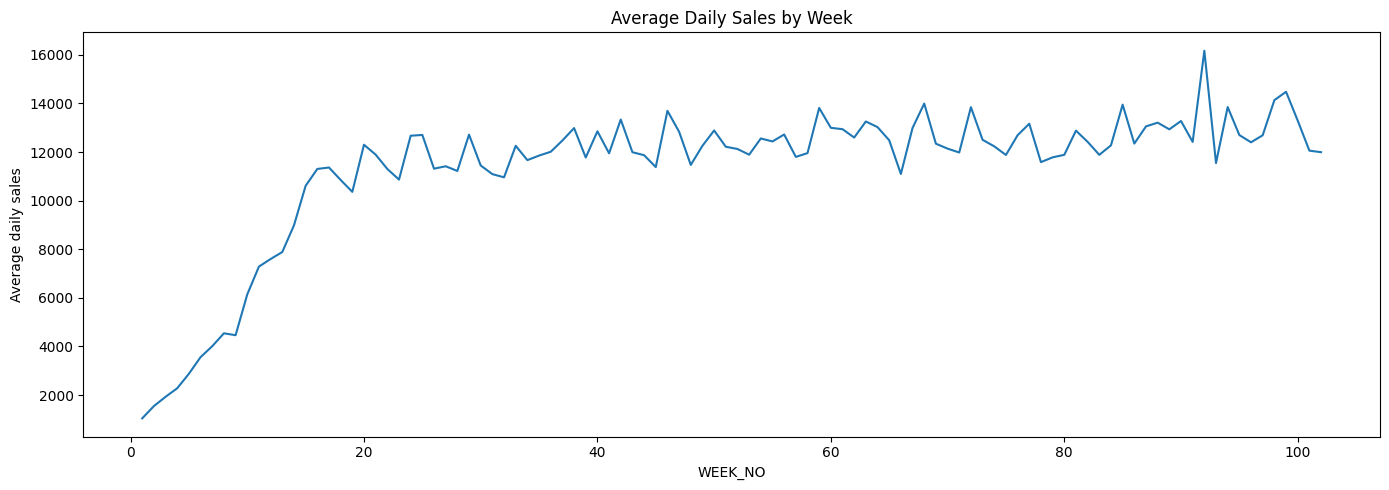

In [ ]:
# Examine changes in average daily sales across weeks
plt.figure(figsize=(14, 5))
plt.plot(
    weekly_sales["WEEK_NO"],
    weekly_sales["AVERAGE_DAILY_SALES"]
)
plt.xlabel("WEEK_NO")
plt.ylabel("Average daily sales")
plt.title("Average Daily Sales by Week")

plt.tight_layout()
plt.show()

In [ ]:
# Measure the relationship between sales and sales seven days earlier
lag_7_correlation = (
    daily_model["DAILY_SALES"]
    .corr(daily_model["DAILY_SALES"].shift(7))
)

print("Correlation between sales and sales 7 days earlier:",
      round(lag_7_correlation, 4))

Correlation between sales and sales 7 days earlier: 0.752


In [ ]:
# Compare sales correlations across important time lags
lag_correlations = {}
for lag in [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]:
    lag_correlations[lag] = (
        daily_model["DAILY_SALES"]
        .corr(daily_model["DAILY_SALES"].shift(lag))
    )
lag_results = pd.DataFrame(
    {
        "LAG_DAYS": list(lag_correlations.keys()),
        "CORRELATION": list(lag_correlations.values())
    }
)
display(lag_results)

,LAG_DAYS,CORRELATION
0,1,0.730613
1,2,0.515941
2,3,0.440390
3,4,0.441869
4,5,0.498867
5,6,0.638338
6,7,0.752013
7,14,0.741068
8,21,0.714339
9,28,0.726439


In [ ]:
# Compare lag-7 correlation with and without the identified coverage anomalies
sales_without_anomalies = daily_model.loc[
    daily_model["DATA_COVERAGE_ANOMALY"] == 0,
    "DAILY_SALES"
]
sales_shifted_without_anomalies = (
    daily_model["DAILY_SALES"]
    .shift(7)
)
valid_lag7 = (
    (daily_model["DATA_COVERAGE_ANOMALY"] == 0) &
    (daily_model["DATA_COVERAGE_ANOMALY"].shift(7).fillna(0) == 0)
)
correlation_without_anomalies = (
    daily_model.loc[valid_lag7, "DAILY_SALES"]
    .corr(
        sales_shifted_without_anomalies.loc[valid_lag7]
    )
)
print(
    "Lag-7 correlation including all days:",
    round(lag_7_correlation, 4)
)
print(
    "Lag-7 correlation excluding coverage anomalies:",
    round(correlation_without_anomalies, 4)
)

Lag-7 correlation including all days: 0.752
Lag-7 correlation excluding coverage anomalies: 0.7788


In [ ]:
# Test stationarity of the original daily sales series
sales_series = daily_model["DAILY_SALES"]
adf_result = adfuller(
    sales_series,
    autolag="AIC"
)
print("ADF statistic:", round(adf_result[0], 4))
print("p-value:", round(adf_result[1], 4))
print("Used lags:", adf_result[2])
print("Number of observations:", adf_result[3])
print("\nCritical values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

ADF statistic: -4.3174
p-value: 0.0004
Used lags: 20
Number of observations: 690

Critical values:
1%: -3.4399
5%: -2.8657
10%: -2.5690


In [ ]:
# First-difference the daily sales series
sales_difference = (
    daily_model["DAILY_SALES"]
    .diff()
    .dropna()
)
print("Differenced observations:", len(sales_difference))
display(
    sales_difference.describe()
)

Differenced observations: 710


,DAILY_SALES
count,710.000000
mean,21.675197
std,2730.180580
min,-16002.210000
25%,-1179.425000
50%,239.990000
75%,1653.955000
max,11827.290000


In [ ]:
# Test stationarity after first differencing
adf_difference = adfuller(
    sales_difference,
    autolag="AIC"
)

print("ADF statistic:", round(adf_difference[0], 4))
print("p-value:", round(adf_difference[1], 4))
print("Used lags:", adf_difference[2])
print("Number of observations:", adf_difference[3])

print("\nCritical values:")

for key, value in adf_difference[4].items():
    print(f"{key}: {value:.4f}")

ADF statistic: -8.8202
p-value: 0.0
Used lags: 20
Number of observations: 689

Critical values:
1%: -3.4399
5%: -2.8657
10%: -2.5690


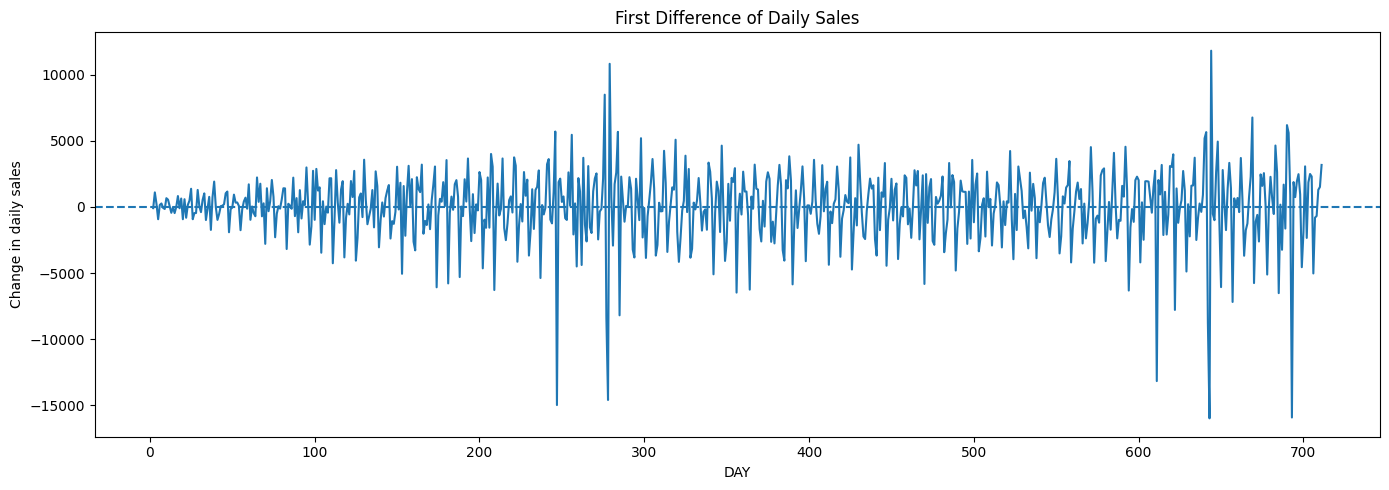

In [ ]:
# Visualise the first-differenced sales series
plt.figure(figsize=(14, 5))
plt.plot(
    daily_model["DAY"].iloc[1:],
    sales_difference
)
plt.axhline(
    0,
    linestyle="--"
)
plt.xlabel("DAY")
plt.ylabel("Change in daily sales")
plt.title("First Difference of Daily Sales")
plt.tight_layout()
plt.show()

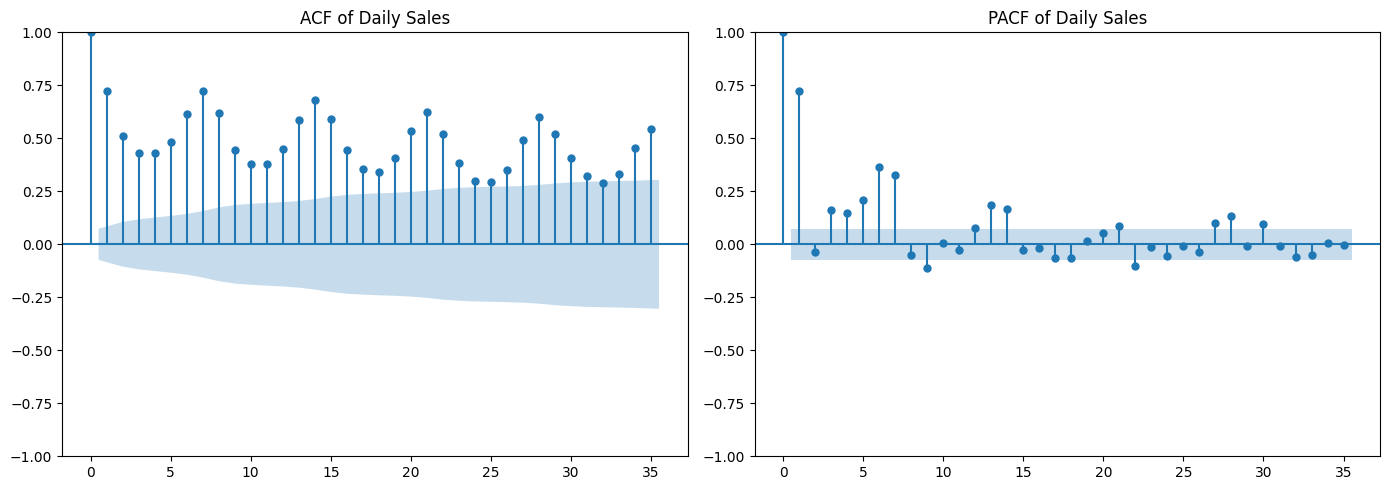

In [ ]:
# Examine autocorrelation in the original daily sales series
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(
    daily_model["DAILY_SALES"],
    lags=35,
    ax=axes[0]
)

plot_pacf(
    daily_model["DAILY_SALES"],
    lags=35,
    ax=axes[1],
    method="ywm"
)
axes[0].set_title("ACF of Daily Sales")
axes[1].set_title("PACF of Daily Sales")
plt.tight_layout()
plt.show()

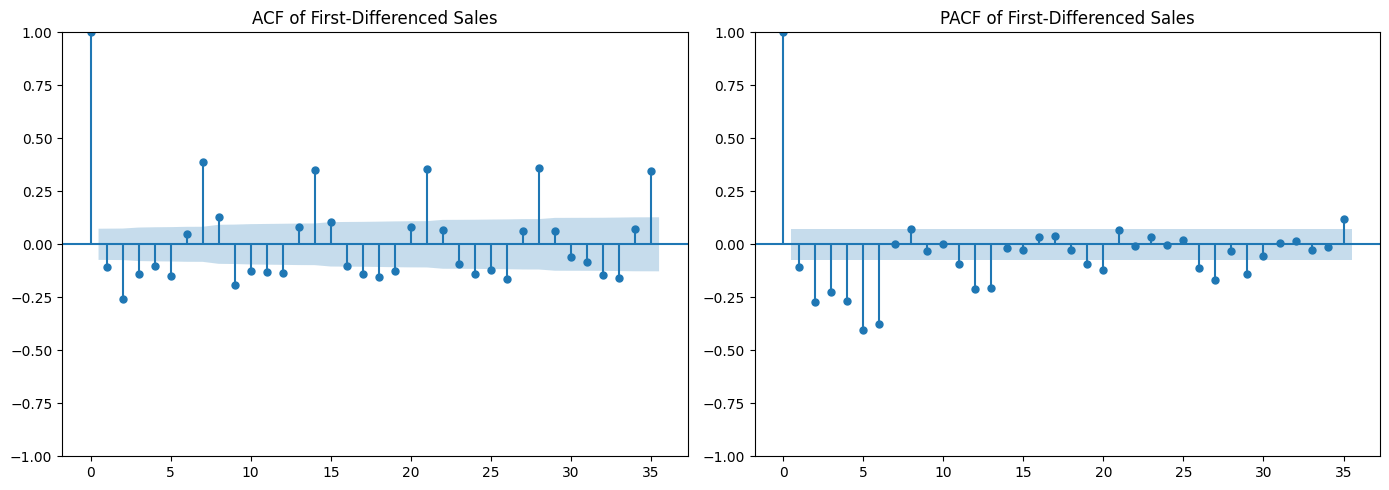

In [ ]:
# Examine autocorrelation after first differencing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(
    sales_difference,
    lags=35,
    ax=axes[0]
)

plot_pacf(
    sales_difference,
    lags=35,
    ax=axes[1],
    method="ywm"
)

axes[0].set_title("ACF of First-Differenced Sales")
axes[1].set_title("PACF of First-Differenced Sales")

plt.tight_layout()
plt.show()

In [ ]:
# Calculate autocorrelation at selected lags
acf_values = {
    lag: daily_model["DAILY_SALES"].autocorr(lag=lag)
    for lag in [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]
}
acf_results = pd.DataFrame(
    {
        "LAG_DAYS": list(acf_values.keys()),
        "ACF": list(acf_values.values())
    }
)
display(acf_results)

,LAG_DAYS,ACF
0,1,0.730613
1,2,0.515941
2,3,0.440390
3,4,0.441869
4,5,0.498867
5,6,0.638338
6,7,0.752013
7,14,0.741068
8,21,0.714339
9,28,0.726439


In [ ]:
# Calculate autocorrelation of the differenced series at selected lags
acf_diff_values = {
    lag: sales_difference.autocorr(lag=lag)
    for lag in [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]
}

acf_diff_results = pd.DataFrame(
    {
        "LAG_DAYS": list(acf_diff_values.keys()),
        "ACF_DIFFERENCED": list(acf_diff_values.values())
    }
)

display(acf_diff_results)

,LAG_DAYS,ACF_DIFFERENCED
0,1,-0.106214
1,2,-0.257763
2,3,-0.140790
3,4,-0.102673
4,5,-0.148434
5,6,0.047091
6,7,0.391489
7,14,0.351863
8,21,0.370187
9,28,0.377294


In [ ]:
# Examine correlations between current sales and previous-day information
correlation_features = [
    "DAILY_SALES",
    "DAILY_QUANTITY",
    "TRANSACTIONS",
    "BASKETS",
    "ACTIVE_HOUSEHOLDS",
    "ACTIVE_PRODUCTS",
    "ACTIVE_STORES",
    "RETAIL_DISCOUNT",
    "COUPON_DISCOUNT",
    "COUPON_MATCH_DISCOUNT"
]
lagged_correlation_results = []
for feature in correlation_features:
    lagged_correlation_results.append(
        {
            "FEATURE": feature,
            "LAG_1_CORRELATION": (
                daily_model["DAILY_SALES"]
                .corr(daily_model[feature].shift(1))
            ),
            "LAG_7_CORRELATION": (
                daily_model["DAILY_SALES"]
                .corr(daily_model[feature].shift(7))
            )
        }
    )

lagged_correlation_results = pd.DataFrame(
    lagged_correlation_results
)
display(
    lagged_correlation_results
    .sort_values(
        "LAG_1_CORRELATION",
        ascending=False
    )
)

,FEATURE,LAG_1_CORRELATION,LAG_7_CORRELATION
4,ACTIVE_HOUSEHOLDS,0.737565,0.770679
3,BASKETS,0.734058,0.772256
0,DAILY_SALES,0.730613,0.752013
5,ACTIVE_PRODUCTS,0.724333,0.759763
2,TRANSACTIONS,0.700420,0.746130
6,ACTIVE_STORES,0.665434,0.676359
1,DAILY_QUANTITY,0.655667,0.575598
9,COUPON_MATCH_DISCOUNT,-0.439977,-0.459714
8,COUPON_DISCOUNT,-0.516052,-0.504905
7,RETAIL_DISCOUNT,-0.679334,-0.716268


In [ ]:
# Create temporary historical sales features for relationship analysis
sales_relationship = pd.DataFrame(
    {
        "CURRENT_SALES": daily_model["DAILY_SALES"],
        "LAG_1": daily_model["DAILY_SALES"].shift(1),
        "LAG_7": daily_model["DAILY_SALES"].shift(7),
        "LAG_14": daily_model["DAILY_SALES"].shift(14),
        "LAG_28": daily_model["DAILY_SALES"].shift(28)
    }
)

display(
    sales_relationship.corr()
)

,CURRENT_SALES,LAG_1,LAG_7,LAG_14,LAG_28
CURRENT_SALES,1.000000,0.730613,0.752013,0.741068,0.726439
LAG_1,0.730613,1.000000,0.637460,0.633968,0.588875
LAG_7,0.752013,0.637460,1.000000,0.751644,0.713826
LAG_14,0.741068,0.633968,0.751644,1.000000,0.748489
LAG_28,0.726439,0.588875,0.713826,0.748489,1.000000


In [ ]:
# Compare historical-sales correlations with and without coverage anomalies
valid_days = (
    (daily_model["DATA_COVERAGE_ANOMALY"] == 0)
    &
    (daily_model["DATA_COVERAGE_ANOMALY"].shift(1).fillna(0) == 0)
    &
    (daily_model["DATA_COVERAGE_ANOMALY"].shift(7).fillna(0) == 0)
    &
    (daily_model["DATA_COVERAGE_ANOMALY"].shift(14).fillna(0) == 0)
    &
    (daily_model["DATA_COVERAGE_ANOMALY"].shift(28).fillna(0) == 0)
)
clean_relationship = sales_relationship.loc[valid_days]
print("Observations used:", len(clean_relationship))
display(
    clean_relationship.corr()
)

Observations used: 701


,CURRENT_SALES,LAG_1,LAG_7,LAG_14,LAG_28
CURRENT_SALES,1.000000,0.767125,0.780514,0.771485,0.759393
LAG_1,0.767125,1.000000,0.680465,0.665515,0.619991
LAG_7,0.780514,0.680465,1.000000,0.779536,0.749154
LAG_14,0.771485,0.665515,0.779536,1.000000,0.778814
LAG_28,0.759393,0.619991,0.749154,0.778814,1.000000


# Phase 5: Feature Engineering

In [ ]:
# Create historical sales features using only information available before each day
for lag in [1, 7, 14, 28]:
    daily_model[f"lag_{lag}"] = (
        daily_model["DAILY_SALES"].shift(lag)
    )
daily_model["rolling_mean_7"] = (
    daily_model["DAILY_SALES"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

daily_model["rolling_mean_14"] = (
    daily_model["DAILY_SALES"]
    .shift(1)
    .rolling(window=14)
    .mean()
)

daily_model["rolling_mean_28"] = (
    daily_model["DAILY_SALES"]
    .shift(1)
    .rolling(window=28)
    .mean()
)

daily_model["rolling_std_7"] = (
    daily_model["DAILY_SALES"]
    .shift(1)
    .rolling(window=7)
    .std()
)

daily_model["rolling_std_28"] = (
    daily_model["DAILY_SALES"]
    .shift(1)
    .rolling(window=28)
    .std()
)

display(
    daily_model[
        [
            "DAY",
            "DAILY_SALES",
            "lag_1",
            "lag_7",
            "lag_14",
            "lag_28",
            "rolling_mean_7",
            "rolling_mean_14",
            "rolling_mean_28",
            "rolling_std_7",
            "rolling_std_28"
        ]
    ].head(35)
)

,DAY,DAILY_SALES,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,rolling_std_7,rolling_std_28
0,1,549.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,458.91,549.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1560.37,458.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1785.64,1560.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,856.93,1785.64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,1008.15,856.93,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,1271.29,1008.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,1203.85,1271.29,549.31,NaN,NaN,1070.085714,NaN,NaN,497.810920,NaN
8,9,1050.95,1203.85,458.91,NaN,NaN,1163.591429,NaN,NaN,442.036307,NaN
9,10,1714.38,1050.95,1560.37,NaN,NaN,1248.168571,NaN,NaN,326.194141,NaN


In [ ]:
# Verify that rolling features use only historical observations
check_day = 29
expected_mean_7 = (
    daily_model.loc[
        daily_model["DAY"].between(check_day - 7, check_day - 1),
        "DAILY_SALES"
    ].mean()
)

actual_mean_7 = daily_model.loc[
    daily_model["DAY"] == check_day,
    "rolling_mean_7"
].iloc[0]

print("Expected rolling mean:", round(expected_mean_7, 4))
print("Stored rolling mean:", round(actual_mean_7, 4))
print(
    "Leakage check passed:",
    np.isclose(expected_mean_7, actual_mean_7)
)

Expected rolling mean: 2240.3114
Stored rolling mean: 2240.3114
Leakage check passed: True


In [ ]:
# Check expected missing values created by lag and rolling features
feature_columns = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_28"
]
display(
    daily_model[feature_columns].isna().sum()
)

,0
lag_1,1
lag_7,7
lag_14,14
lag_28,28
rolling_mean_7,7
rolling_mean_14,14
rolling_mean_28,28
rolling_std_7,7
rolling_std_28,28


In [ ]:
# Create lagged operational and discount features
# Only historical values are used to prevent temporal leakage
lagged_features = [
    "DAILY_QUANTITY",
    "TRANSACTIONS",
    "BASKETS",
    "ACTIVE_HOUSEHOLDS",
    "ACTIVE_PRODUCTS",
    "ACTIVE_STORES",
    "RETAIL_DISCOUNT",
    "COUPON_DISCOUNT",
    "COUPON_MATCH_DISCOUNT"
]

for feature in lagged_features:
    daily_model[f"{feature.lower()}_lag_1"] = (
        daily_model[feature].shift(1)
    )

    daily_model[f"{feature.lower()}_lag_7"] = (
        daily_model[feature].shift(7)
    )

print(
    "New lagged operational/discount features:",
    len(lagged_features) * 2
)

display(
    daily_model[
        [
            "DAY",
            "DAILY_SALES",
            "TRANSACTIONS",
            "transactions_lag_1",
            "transactions_lag_7",
            "BASKETS",
            "baskets_lag_1",
            "baskets_lag_7",
            "RETAIL_DISCOUNT",
            "retail_discount_lag_1",
            "retail_discount_lag_7"
        ]
    ].head(12)
)

New lagged operational/discount features: 18


,DAY,DAILY_SALES,TRANSACTIONS,transactions_lag_1,transactions_lag_7,BASKETS,baskets_lag_1,baskets_lag_7,RETAIL_DISCOUNT,retail_discount_lag_1,retail_discount_lag_7
0,1,549.31,238,NaN,NaN,16,NaN,NaN,-137.54,NaN,NaN
1,2,458.91,137,238.0,NaN,13,16.0,NaN,-95.08,-137.54,NaN
2,3,1560.37,524,137.0,NaN,44,13.0,NaN,-293.35,-95.08,NaN
3,4,1785.64,675,524.0,NaN,44,44.0,NaN,-355.88,-293.35,NaN
4,5,856.93,307,675.0,NaN,25,44.0,NaN,-155.40,-355.88,NaN
5,6,1008.15,338,307.0,NaN,37,25.0,NaN,-255.30,-155.40,NaN
6,7,1271.29,465,338.0,NaN,34,37.0,NaN,-179.62,-255.30,NaN
7,8,1203.85,434,465.0,238.0,43,34.0,16.0,-283.09,-179.62,-137.54
8,9,1050.95,362,434.0,137.0,39,43.0,13.0,-192.00,-283.09,-95.08
9,10,1714.38,490,362.0,524.0,51,39.0,44.0,-356.88,-192.00,-293.35


In [ ]:
# Create time-position features from the established DAY structure
daily_model["DAY_OF_WEEK_CYCLE"] = (
    daily_model["DAY"] - 1
) % 7

daily_model["DAY_TREND"] = daily_model["DAY"]

display(
    daily_model[
        [
            "DAY",
            "WEEK_NO",
            "DAY_OF_WEEK_CYCLE",
            "DAY_TREND"
        ]
    ].head(15)
)

,DAY,WEEK_NO,DAY_OF_WEEK_CYCLE,DAY_TREND
0,1,1,0,1
1,2,1,1,2
2,3,1,2,3
3,4,1,3,4
4,5,1,4,5
5,6,2,5,6
6,7,2,6,7
7,8,2,0,8
8,9,2,1,9
9,10,2,2,10


In [ ]:
# Define the historical features currently available for forecasting
historical_feature_columns = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_28"
]

operational_feature_columns = [
    f"{feature.lower()}_lag_{lag}"
    for feature in lagged_features
    for lag in [1, 7]
]

time_feature_columns = [
    "DAY_TREND",
    "WEEK_NO",
    "DAY_OF_WEEK_CYCLE"
]

forecast_feature_columns = (
    historical_feature_columns
    + operational_feature_columns
    + time_feature_columns
)

print("Historical sales features:", len(historical_feature_columns))
print("Operational/discount features:", len(operational_feature_columns))
print("Time features:", len(time_feature_columns))
print("Total forecasting features:", len(forecast_feature_columns))

display(forecast_feature_columns)

Historical sales features: 9
Operational/discount features: 18
Time features: 3
Total forecasting features: 30


['lag_1',
 'lag_7',
 'lag_14',
 'lag_28',
 'rolling_mean_7',
 'rolling_mean_14',
 'rolling_mean_28',
 'rolling_std_7',
 'rolling_std_28',
 'daily_quantity_lag_1',
 'daily_quantity_lag_7',
 'transactions_lag_1',
 'transactions_lag_7',
 'baskets_lag_1',
 'baskets_lag_7',
 'active_households_lag_1',
 'active_households_lag_7',
 'active_products_lag_1',
 'active_products_lag_7',
 'active_stores_lag_1',
 'active_stores_lag_7',
 'retail_discount_lag_1',
 'retail_discount_lag_7',
 'coupon_discount_lag_1',
 'coupon_discount_lag_7',
 'coupon_match_discount_lag_1',
 'coupon_match_discount_lag_7',
 'DAY_TREND',
 'WEEK_NO',
 'DAY_OF_WEEK_CYCLE']

In [ ]:
# Check that current-day target and contemporaneous operational variables
# are not included in the forecasting feature set
forbidden_features = [
    "DAILY_SALES",
    "DAILY_QUANTITY",
    "TRANSACTIONS",
    "BASKETS",
    "ACTIVE_HOUSEHOLDS",
    "ACTIVE_PRODUCTS",
    "ACTIVE_STORES",
    "RETAIL_DISCOUNT",
    "COUPON_DISCOUNT",
    "COUPON_MATCH_DISCOUNT"
]
forbidden_in_features = [
    feature
    for feature in forbidden_features
    if feature in forecast_feature_columns
]
print(
    "Current-day variables incorrectly included:",
    forbidden_in_features
)

print(
    "Leakage check passed:",
    len(forbidden_in_features) == 0
)

Current-day variables incorrectly included: []
Leakage check passed: True


In [ ]:
# Inspect the data types and promotional codes before transformation
print("Display data type:", causal_data["display"].dtype)
print("Mailer data type:", causal_data["mailer"].dtype)
print("\nUnique display values:")
print(sorted(causal_data["display"].astype(str).unique()))
print("\nUnique mailer values:")
print(sorted(causal_data["mailer"].astype(str).unique()))

Display data type: object
Mailer data type: object

Unique display values:
['0', '1', '2', '3', '4', '5', '6', '7', '9', 'A']

Unique mailer values:
['0', 'A', 'C', 'D', 'F', 'H', 'J', 'L', 'P', 'X', 'Z']


In [ ]:
# Examine how display and mailer combinations occur in the causal data
promo_combinations = (
    causal_data
    .assign(
        display_code=causal_data["display"].astype(str),
        mailer_code=causal_data["mailer"].astype(str)
    )
    .groupby(["display_code", "mailer_code"])
    .size()
    .reset_index(name="ROWS")
    .sort_values("ROWS", ascending=False)
)

display(promo_combinations.head(20))

,display_code,mailer_code,ROWS
0,0,A,14284146
2,0,D,3607593
86,9,0,2398879
53,5,0,1685025
75,7,0,1618969
64,6,0,1546161
32,3,0,1304402
4,0,H,1292966
21,2,0,1126383
3,0,F,1005296


In [ ]:
# Create binary promotion indicators at the product-store-week level
causal_promo = causal_data.copy()
causal_promo["DISPLAY_ACTIVE"] = (
    causal_promo["display"].astype(str) != "0"
).astype(int)

causal_promo["MAILER_ACTIVE"] = (
    causal_promo["mailer"].astype(str) != "0"
).astype(int)
display(
    causal_promo[
        [
            "PRODUCT_ID",
            "STORE_ID",
            "WEEK_NO",
            "display",
            "mailer",
            "DISPLAY_ACTIVE",
            "MAILER_ACTIVE"
        ]
    ].head(20)
)

,PRODUCT_ID,STORE_ID,WEEK_NO,display,mailer,DISPLAY_ACTIVE,MAILER_ACTIVE
0,26190,286,70,0,A,0,1
1,26190,288,70,0,A,0,1
2,26190,289,70,0,A,0,1
3,26190,292,70,0,A,0,1
4,26190,293,70,0,A,0,1
5,26190,295,70,0,A,0,1
6,26190,296,70,0,A,0,1
7,26190,297,70,0,A,0,1
8,26190,298,70,0,A,0,1
9,26190,299,70,0,A,0,1


In [ ]:
# Collapse multiple causal records to one product-store-week observation
# using the presence of any display or mailer activity
product_store_week_promo = (
    causal_promo
    .groupby(
        ["PRODUCT_ID", "STORE_ID", "WEEK_NO"],
        as_index=False
    )
    .agg(
        DISPLAY_ACTIVE=("DISPLAY_ACTIVE", "max"),
        MAILER_ACTIVE=("MAILER_ACTIVE", "max")
    )
)

print(
    "Product-store-week observations:",
    len(product_store_week_promo)
)

print(
    "Duplicate product-store-week keys:",
    product_store_week_promo.duplicated(
        ["PRODUCT_ID", "STORE_ID", "WEEK_NO"]
    ).sum()
)

display(product_store_week_promo.head())

Product-store-week observations: 36771279
Duplicate product-store-week keys: 0


,PRODUCT_ID,STORE_ID,WEEK_NO,DISPLAY_ACTIVE,MAILER_ACTIVE
0,26190,286,70,0,1
1,26190,288,70,0,1
2,26190,289,70,0,1
3,26190,292,70,0,1
4,26190,293,70,0,1


In [ ]:
# Aggregate product-store-week promotion indicators to the weekly level
weekly_promotion = (
    product_store_week_promo
    .groupby("WEEK_NO")
    .agg(
        PROMOTIONAL_PRODUCT_STORE_COMBINATIONS=("PRODUCT_ID", "size"),
        DISPLAY_ACTIVE_COMBINATIONS=("DISPLAY_ACTIVE", "sum"),
        MAILER_ACTIVE_COMBINATIONS=("MAILER_ACTIVE", "sum"),
        PROMOTED_PRODUCTS=("PRODUCT_ID", "nunique")
    )
    .reset_index()
)

weekly_promotion["DISPLAY_RATE"] = (
    weekly_promotion["DISPLAY_ACTIVE_COMBINATIONS"]
    / weekly_promotion["PROMOTIONAL_PRODUCT_STORE_COMBINATIONS"]
)

weekly_promotion["MAILER_RATE"] = (
    weekly_promotion["MAILER_ACTIVE_COMBINATIONS"]
    / weekly_promotion["PROMOTIONAL_PRODUCT_STORE_COMBINATIONS"]
)

display(weekly_promotion.head(15))
display(weekly_promotion.describe())

,WEEK_NO,PROMOTIONAL_PRODUCT_STORE_COMBINATIONS,DISPLAY_ACTIVE_COMBINATIONS,MAILER_ACTIVE_COMBINATIONS,PROMOTED_PRODUCTS,DISPLAY_RATE,MAILER_RATE
0,9,398116,187464,263744,21543,0.470878,0.662480
1,10,346537,164679,228877,20442,0.475213,0.660469
2,11,498393,174246,388873,21774,0.349616,0.780254
3,12,374521,178569,240591,21251,0.476793,0.642397
4,13,422183,175863,297851,21266,0.416556,0.705502
5,14,375968,177594,247289,20657,0.472365,0.657739
6,15,384692,181952,255244,20526,0.472981,0.663502
7,16,542901,157301,441985,20242,0.289742,0.814117
8,17,389506,177330,255476,21253,0.455269,0.655897
9,18,355727,177184,220625,21326,0.498090,0.620209


,WEEK_NO,PROMOTIONAL_PRODUCT_STORE_COMBINATIONS,DISPLAY_ACTIVE_COMBINATIONS,MAILER_ACTIVE_COMBINATIONS,PROMOTED_PRODUCTS,DISPLAY_RATE,MAILER_RATE
count,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000
mean,55.000000,395390.096774,169330.559140,271367.655914,22034.268817,0.434661,0.680051
std,26.990739,54236.965721,9235.698227,59459.292216,736.456545,0.052398,0.050839
min,9.000000,308916.000000,136430.000000,177642.000000,20242.000000,0.285717,0.575050
25%,32.000000,362163.000000,163484.000000,235876.000000,21543.000000,0.415929,0.650117
50%,55.000000,384692.000000,169293.000000,259228.000000,22011.000000,0.445725,0.671030
75%,78.000000,412552.000000,175884.000000,289247.000000,22487.000000,0.467619,0.701614
max,101.000000,589473.000000,188625.000000,481217.000000,24225.000000,0.534304,0.816351


In [ ]:
# Check promotional coverage against the full transaction period
promotion_week_set = set(
    weekly_promotion["WEEK_NO"]
)
daily_model["PROMOTION_DATA_AVAILABLE"] = (
    daily_model["WEEK_NO"]
    .isin(promotion_week_set)
).astype(int)
print(
    "Days with promotional information:",
    daily_model["PROMOTION_DATA_AVAILABLE"].sum()
)
print(
    "Days without promotional information:",
    (
        daily_model["PROMOTION_DATA_AVAILABLE"] == 0
    ).sum()
)
display(
    daily_model[
        ["DAY", "WEEK_NO", "PROMOTION_DATA_AVAILABLE"]
    ].head(60)
)

Days with promotional information: 651
Days without promotional information: 60


,DAY,WEEK_NO,PROMOTION_DATA_AVAILABLE
0,1,1,0
1,2,1,0
2,3,1,0
3,4,1,0
4,5,1,0
5,6,2,0
6,7,2,0
7,8,2,0
8,9,2,0
9,10,2,0


In [ ]:
# Inspect campaign timing information
print("Campaigns:", len(campaign_desc))
display(
    campaign_desc.sort_values("START_DAY")
)

Campaigns: 30


,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
29,TypeA,26,224,264
28,TypeC,27,237,300
27,TypeB,28,259,320
26,TypeB,29,281,334
25,TypeA,30,323,369
23,TypeB,1,346,383
24,TypeB,2,351,383
20,TypeC,3,356,412
22,TypeB,4,372,404
21,TypeB,5,377,411


In [ ]:
# Determine which transaction weeks overlap each campaign period
campaign_week_records = []
for _, campaign in campaign_desc.iterrows():

    overlapping_weeks = day_week_mapping.loc[
        day_week_mapping["DAY"].between(
            campaign["START_DAY"],
            campaign["END_DAY"]
        ),
        "WEEK_NO"
    ].unique()

    for week in overlapping_weeks:
        campaign_week_records.append(
            {
                "CAMPAIGN": campaign["CAMPAIGN"],
                "DESCRIPTION": campaign["DESCRIPTION"],
                "START_DAY": campaign["START_DAY"],
                "END_DAY": campaign["END_DAY"],
                "WEEK_NO": week
            }
        )

campaign_week_mapping = pd.DataFrame(
    campaign_week_records
)

display(
    campaign_week_mapping.sort_values(
        ["WEEK_NO", "CAMPAIGN"]
    ).head(30)
)

,CAMPAIGN,DESCRIPTION,START_DAY,END_DAY,WEEK_NO
207,26,TypeA,224,264,33
209,26,TypeA,224,264,34
208,26,TypeA,224,264,35
197,27,TypeC,237,300,35
210,26,TypeA,224,264,36
198,27,TypeC,237,300,36
211,26,TypeA,224,264,37
199,27,TypeC,237,300,37
212,26,TypeA,224,264,38
200,27,TypeC,237,300,38


In [ ]:
# Compare causal weeks with campaign-active weeks
campaign_weeks = set(
    campaign_week_mapping["WEEK_NO"].unique()
)
causal_weeks = set(
    causal_data["WEEK_NO"].unique()
)
print(
    "Causal weeks:",
    len(causal_weeks)
)
print(
    "Campaign-active weeks:",
    len(campaign_weeks)
)
print(
    "Causal weeks overlapping campaigns:",
    len(causal_weeks & campaign_weeks)
)
print(
    "Causal weeks without campaign overlap:",
    len(causal_weeks - campaign_weeks)
)
print(
    "Campaign weeks without causal data:",
    len(campaign_weeks - causal_weeks)
)

Causal weeks: 93
Campaign-active weeks: 70
Causal weeks overlapping campaigns: 69
Causal weeks without campaign overlap: 24
Campaign weeks without causal data: 1


In [ ]:
# Check whether the identified coverage anomalies fall within campaigns
anomaly_campaigns = campaign_desc[
    campaign_desc.apply(
        lambda row: (
            row["START_DAY"] <= 643
            and row["END_DAY"] >= 278
        ),
        axis=1
    )
]

display(anomaly_campaigns)

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
1,TypeC,15,547,708
3,TypeC,20,615,685
5,TypeB,21,624,656
6,TypeB,22,624,656
7,TypeA,18,587,642
8,TypeB,19,603,635
9,TypeB,17,575,607
10,TypeC,14,531,596
11,TypeB,16,561,593
12,TypeA,13,504,551


In [ ]:
print("Campaign weeks without causal data:")
print(sorted(campaign_weeks - causal_weeks))
print("\nCausal weeks without campaign overlap:")
print(sorted(causal_weeks - campaign_weeks))

Campaign weeks without causal data:
[np.int64(102)]

Causal weeks without campaign overlap:
[np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32)]


In [ ]:
for day in [278, 643]:
    active_campaigns = campaign_desc[
        (campaign_desc["START_DAY"] <= day)
        & (campaign_desc["END_DAY"] >= day)
    ]

    print("\nDAY:", day)
    print("Active campaigns:", len(active_campaigns))

    if len(active_campaigns) > 0:
        display(active_campaigns)
    else:
        print("No active campaign")


DAY: 278
Active campaigns: 2


,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
27,TypeB,28,259,320
28,TypeC,27,237,300



DAY: 643
Active campaigns: 4


,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
1,TypeC,15,547,708
3,TypeC,20,615,685
5,TypeB,21,624,656
6,TypeB,22,624,656


In [ ]:
causal_products = set(causal_data["PRODUCT_ID"].unique())
transaction_products = set(transaction["PRODUCT_ID"].unique())
causal_stores = set(causal_data["STORE_ID"].unique())
transaction_stores = set(transaction["STORE_ID"].unique())
print("Product overlap")
print("Transaction products:", len(transaction_products))
print("Causal products:", len(causal_products))
print("Products in both:", len(transaction_products & causal_products))
print("Transaction products without causal data:", len(transaction_products - causal_products))
print("\nStore overlap")
print("Transaction stores:", len(transaction_stores))
print("Causal stores:", len(causal_stores))
print("Stores in both:", len(transaction_stores & causal_stores))
print("Transaction stores without causal data:", len(transaction_stores - causal_stores))

Product overlap
Transaction products: 92339
Causal products: 68377
Products in both: 68377
Transaction products without causal data: 23962

Store overlap
Transaction stores: 582
Causal stores: 115
Stores in both: 115
Transaction stores without causal data: 467


In [ ]:
# Transaction activity occurring in stores covered by causal data
transaction_in_causal_stores = transaction[
    transaction["STORE_ID"].isin(causal_stores)
]
total_sales = transaction["SALES_VALUE"].sum()
covered_sales = transaction_in_causal_stores["SALES_VALUE"].sum()
total_transactions = len(transaction)
covered_transactions = len(transaction_in_causal_stores)
sales_coverage = covered_sales / total_sales
transaction_coverage = covered_transactions / total_transactions
print("Share of transaction sales from causal-data stores:")
print(round(sales_coverage, 4))
print("\nShare of transaction rows from causal-data stores:")
print(round(transaction_coverage, 4))

Share of transaction sales from causal-data stores:
0.9849

Share of transaction rows from causal-data stores:
0.9857


In [ ]:
weekly_promotion = weekly_promotion.sort_values("WEEK_NO").copy()
promotion_features = [
    "DISPLAY_RATE",
    "MAILER_RATE",
    "PROMOTED_PRODUCTS",
    "DISPLAY_ACTIVE_COMBINATIONS",
    "MAILER_ACTIVE_COMBINATIONS"
]

for feature in promotion_features:
    weekly_promotion[f"{feature}_LAG_1"] = (
        weekly_promotion[feature].shift(1)
    )

print("Weekly promotion table shape:", weekly_promotion.shape)

print("\nMissing values in original promotion features:")
print(weekly_promotion[promotion_features].isna().sum())

print("\nMissing values in lagged promotion features:")
print(
    weekly_promotion[
        [f"{feature}_LAG_1" for feature in promotion_features]
    ].isna().sum()
)

display(
    weekly_promotion[
        [
            "WEEK_NO",
            "DISPLAY_RATE",
            "MAILER_RATE",
            "PROMOTED_PRODUCTS",
            "DISPLAY_RATE_LAG_1",
            "MAILER_RATE_LAG_1",
            "PROMOTED_PRODUCTS_LAG_1"
        ]
    ].head(15)
)

Weekly promotion table shape: (93, 12)

Missing values in original promotion features:
DISPLAY_RATE                   0
MAILER_RATE                    0
PROMOTED_PRODUCTS              0
DISPLAY_ACTIVE_COMBINATIONS    0
MAILER_ACTIVE_COMBINATIONS     0
dtype: int64

Missing values in lagged promotion features:
DISPLAY_RATE_LAG_1                   1
MAILER_RATE_LAG_1                    1
PROMOTED_PRODUCTS_LAG_1              1
DISPLAY_ACTIVE_COMBINATIONS_LAG_1    1
MAILER_ACTIVE_COMBINATIONS_LAG_1     1
dtype: int64


,WEEK_NO,DISPLAY_RATE,MAILER_RATE,PROMOTED_PRODUCTS,DISPLAY_RATE_LAG_1,MAILER_RATE_LAG_1,PROMOTED_PRODUCTS_LAG_1
0,9,0.470878,0.662480,21543,NaN,NaN,NaN
1,10,0.475213,0.660469,20442,0.470878,0.662480,21543.0
2,11,0.349616,0.780254,21774,0.475213,0.660469,20442.0
3,12,0.476793,0.642397,21251,0.349616,0.780254,21774.0
4,13,0.416556,0.705502,21266,0.476793,0.642397,21251.0
5,14,0.472365,0.657739,20657,0.416556,0.705502,21266.0
6,15,0.472981,0.663502,20526,0.472365,0.657739,20657.0
7,16,0.289742,0.814117,20242,0.472981,0.663502,20526.0
8,17,0.455269,0.655897,21253,0.289742,0.814117,20242.0
9,18,0.498090,0.620209,21326,0.455269,0.655897,21253.0


In [ ]:
lagged_promotion_features = [
    "DISPLAY_RATE_LAG_1",
    "MAILER_RATE_LAG_1",
    "PROMOTED_PRODUCTS_LAG_1",
    "DISPLAY_ACTIVE_COMBINATIONS_LAG_1",
    "MAILER_ACTIVE_COMBINATIONS_LAG_1"
]

promotion_merge = weekly_promotion[
    ["WEEK_NO"] + lagged_promotion_features
].copy()

daily_model = daily_model.merge(
    promotion_merge,
    on="WEEK_NO",
    how="left",
    validate="many_to_one"
)

print("Daily modelling table shape:", daily_model.shape)

print("\nMissing values in lagged promotion features:")
print(
    daily_model[lagged_promotion_features]
    .isna()
    .sum()
)
print("\nDays with unavailable lagged promotion information:")
print(
    daily_model[lagged_promotion_features]
    .isna()
    .any(axis=1)
    .sum()
)
print("\nWeeks with unavailable lagged promotion information:")
print(
    daily_model.loc[
        daily_model[lagged_promotion_features]
        .isna()
        .any(axis=1),
        "WEEK_NO"
    ].unique()
)

Daily modelling table shape: (711, 50)

Missing values in lagged promotion features:
DISPLAY_RATE_LAG_1                   67
MAILER_RATE_LAG_1                    67
PROMOTED_PRODUCTS_LAG_1              67
DISPLAY_ACTIVE_COMBINATIONS_LAG_1    67
MAILER_ACTIVE_COMBINATIONS_LAG_1     67
dtype: int64

Days with unavailable lagged promotion information:
67

Weeks with unavailable lagged promotion information:
[  1   2   3   4   5   6   7   8   9 102]


In [ ]:
print("Expected daily observations:", 711)
print("Actual daily observations:", len(daily_model))
print("Unique DAY values:", daily_model["DAY"].nunique())
print("Duplicate DAY values:", daily_model["DAY"].duplicated().sum())
print(
    "Promotion merge check:",
    len(daily_model) == 711
    and daily_model["DAY"].nunique() == 711
    and daily_model["DAY"].duplicated().sum() == 0
)

Expected daily observations: 711
Actual daily observations: 711
Unique DAY values: 711
Duplicate DAY values: 0
Promotion merge check: True


In [ ]:
historical_features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_28"
]
print("Total daily observations:", len(daily_model))
print("\nMissing historical features:")
print(
    daily_model[historical_features]
    .isna()
    .sum()
)
print("\nFirst day with all historical features available:")
print(
    daily_model.loc[
        daily_model[historical_features].notna().all(axis=1),
        "DAY"
    ].min()
)

print("\nFirst day with all historical and promotion features available:")
print(
    daily_model.loc[
        daily_model[
            historical_features + lagged_promotion_features
        ].notna().all(axis=1),
        "DAY"
    ].min()
)

Total daily observations: 711

Missing historical features:
lag_1               1
lag_7               7
lag_14             14
lag_28             28
rolling_mean_7      7
rolling_mean_14    14
rolling_mean_28    28
rolling_std_7       7
rolling_std_28     28
dtype: int64

First day with all historical features available:
29

First day with all historical and promotion features available:
62


In [ ]:
historical_usable = daily_model[
    daily_model[historical_features]
    .notna()
    .all(axis=1)
].copy()

promotion_usable = daily_model[
    daily_model[
        historical_features + lagged_promotion_features
    ].notna()
    .all(axis=1)
].copy()

print("Historical-model usable observations:", len(historical_usable))
print("Promotion-model usable observations:", len(promotion_usable))

print("\nHistorical-model day range:")
print(
    historical_usable["DAY"].min(),
    "to",
    historical_usable["DAY"].max()
)

print("\nPromotion-model day range:")
print(
    promotion_usable["DAY"].min(),
    "to",
    promotion_usable["DAY"].max()
)

Historical-model usable observations: 683
Promotion-model usable observations: 644

Historical-model day range:
29 to 711

Promotion-model day range:
62 to 705


In [ ]:
common_start = 62
common_end = 705
common_period = daily_model[
    daily_model["DAY"].between(common_start, common_end)
].copy()
print("Common evaluation period:")
print("Start day:", common_period["DAY"].min())
print("End day:", common_period["DAY"].max())
print("Observations:", len(common_period))
print("\nMissing historical features:")
print(
    common_period[historical_features]
    .isna()
    .sum()
)
print("\nMissing promotion features:")
print(
    common_period[lagged_promotion_features]
    .isna()
    .sum()
)
print("\nDuplicate days:", common_period["DAY"].duplicated().sum())

Common evaluation period:
Start day: 62
End day: 705
Observations: 644

Missing historical features:
lag_1              0
lag_7              0
lag_14             0
lag_28             0
rolling_mean_7     0
rolling_mean_14    0
rolling_mean_28    0
rolling_std_7      0
rolling_std_28     0
dtype: int64

Missing promotion features:
DISPLAY_RATE_LAG_1                   0
MAILER_RATE_LAG_1                    0
PROMOTED_PRODUCTS_LAG_1              0
DISPLAY_ACTIVE_COMBINATIONS_LAG_1    0
MAILER_ACTIVE_COMBINATIONS_LAG_1     0
dtype: int64

Duplicate days: 0


# Phase 6: Define the chronological modelling split

In [ ]:
common_start = 62
common_end = 705

modeling_data = daily_model[
    daily_model["DAY"].between(common_start, common_end)
].copy()

n_observations = len(modeling_data)

train_end_index = int(n_observations * 0.70)
validation_end_index = int(n_observations * 0.85)

train_df = modeling_data.iloc[:train_end_index].copy()

validation_df = modeling_data.iloc[
    train_end_index:validation_end_index
].copy()

test_df = modeling_data.iloc[
    validation_end_index:
].copy()

print("Total observations:", len(modeling_data))

print("\nTraining set:")
print("Days:", train_df["DAY"].min(), "to", train_df["DAY"].max())
print("Observations:", len(train_df))

print("\nValidation set:")
print(
    "Days:",
    validation_df["DAY"].min(),
    "to",
    validation_df["DAY"].max()
)
print("Observations:", len(validation_df))

print("\nTest set:")
print("Days:", test_df["DAY"].min(), "to", test_df["DAY"].max())
print("Observations:", len(test_df))

print("\nTotal split observations:")
print(
    len(train_df)
    + len(validation_df)
    + len(test_df)
)

Total observations: 644

Training set:
Days: 62 to 511
Observations: 450

Validation set:
Days: 512 to 608
Observations: 97

Test set:
Days: 609 to 705
Observations: 97

Total split observations:
644


In [ ]:
print("Chronological split check:")
print(
    "Training before validation:",
    train_df["DAY"].max() < validation_df["DAY"].min()
)

print(
    "Validation before test:",
    validation_df["DAY"].max() < test_df["DAY"].min()
)

print(
    "No overlap:",
    set(train_df["DAY"]).isdisjoint(validation_df["DAY"])
    and set(train_df["DAY"]).isdisjoint(test_df["DAY"])
    and set(validation_df["DAY"]).isdisjoint(test_df["DAY"])
)

print(
    "All observations retained:",
    len(train_df)
    + len(validation_df)
    + len(test_df)
    == len(modeling_data)
)

Chronological split check:
Training before validation: True
Validation before test: True
No overlap: True
All observations retained: True


# Phase 7: Create the modelling matrices

In [ ]:
historical_features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_28",
    "daily_quantity_lag_1",
    "daily_quantity_lag_7",
    "transactions_lag_1",
    "transactions_lag_7",
    "baskets_lag_1",
    "baskets_lag_7",
    "active_households_lag_1",
    "active_households_lag_7",
    "active_products_lag_1",
    "active_products_lag_7",
    "active_stores_lag_1",
    "active_stores_lag_7",
    "retail_discount_lag_1",
    "retail_discount_lag_7",
    "coupon_discount_lag_1",
    "coupon_discount_lag_7",
    "coupon_match_discount_lag_1",
    "coupon_match_discount_lag_7",
    "DAY_TREND",
    "WEEK_NO",
    "DAY_OF_WEEK_CYCLE"
]

promotion_features = [
    "DISPLAY_RATE_LAG_1",
    "MAILER_RATE_LAG_1",
    "PROMOTED_PRODUCTS_LAG_1",
    "DISPLAY_ACTIVE_COMBINATIONS_LAG_1",
    "MAILER_ACTIVE_COMBINATIONS_LAG_1"
]

target = "DAILY_SALES"

historical_feature_count = len(historical_features)
promotion_feature_count = len(promotion_features)

print("Historical features:", historical_feature_count)
print("Promotion features:", promotion_feature_count)
print(
    "Promotion-enhanced features:",
    historical_feature_count + promotion_feature_count
)

Historical features: 30
Promotion features: 5
Promotion-enhanced features: 35


In [ ]:
X_train_hist = train_df[historical_features].copy()
X_validation_hist = validation_df[historical_features].copy()
X_test_hist = test_df[historical_features].copy()
X_train_promo = train_df[
    historical_features + promotion_features
].copy()
X_validation_promo = validation_df[
    historical_features + promotion_features
].copy()
X_test_promo = test_df[
    historical_features + promotion_features
].copy()
y_train = train_df[target].copy()
y_validation = validation_df[target].copy()
y_test = test_df[target].copy()

In [ ]:
print("Historical feature matrix shapes:")
print("Train:", X_train_hist.shape)
print("Validation:", X_validation_hist.shape)
print("Test:", X_test_hist.shape)
print("\nPromotion-enhanced feature matrix shapes:")
print("Train:", X_train_promo.shape)
print("Validation:", X_validation_promo.shape)
print("Test:", X_test_promo.shape)
print("\nTarget shapes:")
print("Train:", y_train.shape)
print("Validation:", y_validation.shape)
print("Test:", y_test.shape)

Historical feature matrix shapes:
Train: (450, 30)
Validation: (97, 30)
Test: (97, 30)

Promotion-enhanced feature matrix shapes:
Train: (450, 35)
Validation: (97, 35)
Test: (97, 35)

Target shapes:
Train: (450,)
Validation: (97,)
Test: (97,)


In [ ]:
for name, data in {
    "X_train_hist": X_train_hist,
    "X_validation_hist": X_validation_hist,
    "X_test_hist": X_test_hist,
    "X_train_promo": X_train_promo,
    "X_validation_promo": X_validation_promo,
    "X_test_promo": X_test_promo,
}.items():
    print(
        name,
        "| missing:", data.isna().sum().sum(),
        "| infinite:", np.isinf(data.select_dtypes(include=np.number)).sum().sum()
    )
forbidden_features = [
    "DAILY_SALES",
    "DAILY_QUANTITY",
    "TRANSACTIONS",
    "BASKETS",
    "ACTIVE_HOUSEHOLDS",
    "ACTIVE_PRODUCTS",
    "ACTIVE_STORES",
    "RETAIL_DISCOUNT",
    "COUPON_DISCOUNT",
    "COUPON_MATCH_DISCOUNT",
    "DISPLAY_RATE",
    "MAILER_RATE",
    "PROMOTED_PRODUCTS",
    "DISPLAY_ACTIVE_COMBINATIONS",
    "MAILER_ACTIVE_COMBINATIONS"
]
historical_leakage = [
    feature for feature in forbidden_features
    if feature in historical_features
]

promotion_leakage = [
    feature for feature in forbidden_features
    if feature in historical_features + promotion_features
]
print("\nCurrent-day leakage in historical model:", historical_leakage)
print("Current-day leakage in promotion model:", promotion_leakage)

X_train_hist | missing: 0 | infinite: 0
X_validation_hist | missing: 0 | infinite: 0
X_test_hist | missing: 0 | infinite: 0
X_train_promo | missing: 0 | infinite: 0
X_validation_promo | missing: 0 | infinite: 0
X_test_promo | missing: 0 | infinite: 0

Current-day leakage in historical model: []
Current-day leakage in promotion model: []


# Phase 8: Establish forecasting baselines

In [ ]:
test_days = test_df["DAY"].to_numpy()
actual_test_sales = y_test.to_numpy()

naive_predictions = (
    daily_model.set_index("DAY")
    .loc[test_days - 1, "DAILY_SALES"]
    .to_numpy()
)

seasonal_naive_predictions = (
    daily_model.set_index("DAY")
    .loc[test_days - 7, "DAILY_SALES"]
    .to_numpy()
)

print("Naïve predictions:", len(naive_predictions))
print("Seasonal naïve predictions:", len(seasonal_naive_predictions))
print("Actual test observations:", len(actual_test_sales))

Naïve predictions: 97
Seasonal naïve predictions: 97
Actual test observations: 97


In [ ]:
def calculate_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    non_zero_actual = actual != 0
    mape = np.mean(
        np.abs(
            (actual[non_zero_actual] - predicted[non_zero_actual])
            / actual[non_zero_actual]
        )
    ) * 100

    r2 = r2_score(actual, predicted)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }
naive_metrics = calculate_metrics(
    actual_test_sales,
    naive_predictions
)
seasonal_naive_metrics = calculate_metrics(
    actual_test_sales,
    seasonal_naive_predictions
)
baseline_results = pd.DataFrame(
    [naive_metrics, seasonal_naive_metrics],
    index=["Naive", "Seasonal Naive"]
)
display(baseline_results)

,MAE,RMSE,MAPE,R2
Naive,2883.263093,4197.674053,5539.687089,-0.358343
Seasonal Naive,2907.854536,4019.817739,4535.019447,-0.245675


In [ ]:
print("Baseline prediction checks:")
print(
    "Naïve prediction length correct:",
    len(naive_predictions) == len(y_test)
)
print(
    "Seasonal naïve prediction length correct:",
    len(seasonal_naive_predictions) == len(y_test)
)
print(
    "Naïve predictions finite:",
    np.isfinite(naive_predictions).all()
)
print(
    "Seasonal naïve predictions finite:",
    np.isfinite(seasonal_naive_predictions).all()
)
print(
    "Actual values finite:",
    np.isfinite(actual_test_sales).all()
)

Baseline prediction checks:
Naïve prediction length correct: True
Seasonal naïve prediction length correct: True
Naïve predictions finite: True
Seasonal naïve predictions finite: True
Actual values finite: True


In [ ]:
test_summary = test_df[
    ["DAY", "DAILY_SALES"]
].copy()

test_summary["NAIVE_PREDICTION"] = naive_predictions
test_summary["SEASONAL_NAIVE_PREDICTION"] = seasonal_naive_predictions

test_summary["NAIVE_ABSOLUTE_ERROR"] = (
    np.abs(
        test_summary["DAILY_SALES"]
        - test_summary["NAIVE_PREDICTION"]
    )
)
test_summary["SEASONAL_NAIVE_ABSOLUTE_ERROR"] = (
    np.abs(
        test_summary["DAILY_SALES"]
        - test_summary["SEASONAL_NAIVE_PREDICTION"]
    )
)

test_summary["NAIVE_APE"] = (
    test_summary["NAIVE_ABSOLUTE_ERROR"]
    / test_summary["DAILY_SALES"]
) * 100

test_summary["SEASONAL_NAIVE_APE"] = (
    test_summary["SEASONAL_NAIVE_ABSOLUTE_ERROR"]
    / test_summary["DAILY_SALES"]
) * 100

display(
    test_summary.sort_values(
        "DAILY_SALES"
    ).head(15)
)

,DAY,DAILY_SALES,NAIVE_PREDICTION,SEASONAL_NAIVE_PREDICTION,NAIVE_ABSOLUTE_ERROR,SEASONAL_NAIVE_ABSOLUTE_ERROR,NAIVE_APE,SEASONAL_NAIVE_APE
642,643,2.99,16005.20,13093.74,16002.21,13090.75,535190.969900,437817.725753
610,611,6962.69,20144.70,11743.41,13182.01,4780.72,189.323523,68.661968
692,693,7573.73,23511.82,13986.46,15938.09,6412.73,210.439110,84.670697
611,612,8996.58,6962.69,13692.13,2033.89,4695.55,22.607369,52.192611
672,673,9010.78,11626.08,9249.14,2615.30,238.36,29.024124,2.645276
699,700,9089.60,11007.90,7573.73,1918.30,1515.87,21.104339,16.676971
665,666,9249.14,10498.28,11441.00,1249.14,2191.86,13.505472,23.697987
693,694,9457.07,7573.73,10744.16,1883.34,1287.09,19.914625,13.609818
630,631,9486.49,11713.49,12020.49,2227.00,2534.00,23.475490,26.711671
617,618,9499.69,10060.04,6962.69,560.35,2537.00,5.898614,26.706135


In [ ]:
def calculate_forecast_metrics(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mape = np.mean(
        np.abs(
            (actual - predicted) / actual
        )
    ) * 100

    smape = np.mean(
        2 * np.abs(actual - predicted)
        / (
            np.abs(actual)
            + np.abs(predicted)
        )
    ) * 100

    wape = (
        np.sum(np.abs(actual - predicted))
        / np.sum(np.abs(actual))
    ) * 100

    r2 = r2_score(actual, predicted)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "sMAPE": smape,
        "WAPE": wape,
        "R2": r2
    }

In [ ]:
baseline_metrics = pd.DataFrame(
    [
        calculate_forecast_metrics(
            actual_test_sales,
            naive_predictions
        ),
        calculate_forecast_metrics(
            actual_test_sales,
            seasonal_naive_predictions
        )
    ],
    index=[
        "Naive",
        "Seasonal Naive"
    ]
)

display(baseline_metrics)

,MAE,RMSE,MAPE,sMAPE,WAPE,R2
Naive,2883.263093,4197.674053,5539.687089,22.939250,21.844524,-0.358343
Seasonal Naive,2907.854536,4019.817739,4535.019447,23.434076,22.030837,-0.245675


In [ ]:
sensitivity_mask = test_df["DAY"].to_numpy() != 643
actual_sensitivity = actual_test_sales[sensitivity_mask]
naive_sensitivity = naive_predictions[sensitivity_mask]
seasonal_naive_sensitivity = (
    seasonal_naive_predictions[sensitivity_mask]
)
baseline_sensitivity = pd.DataFrame(
    [
        calculate_forecast_metrics(
            actual_sensitivity,
            naive_sensitivity
        ),
        calculate_forecast_metrics(
            actual_sensitivity,
            seasonal_naive_sensitivity
        )
    ],
    index=[
        "Naive",
        "Seasonal Naive"
    ]
)
display(baseline_sensitivity)

,MAE,RMSE,MAPE,sMAPE,WAPE,R2
Naive,2746.607396,3890.579726,22.486227,21.095646,20.594697,-0.342571
Seasonal Naive,2801.782708,3813.420552,21.657923,21.595799,21.008414,-0.289846


# Phase 9: Auto ARIMA

In [ ]:
arima_train = train_df[
    ["DAY", "DAILY_SALES"]
].copy()
arima_validation = validation_df[
    ["DAY", "DAILY_SALES"]
].copy()
arima_test = test_df[
    ["DAY", "DAILY_SALES"]
].copy()
y_arima_train = arima_train["DAILY_SALES"].to_numpy()
y_arima_validation = arima_validation["DAILY_SALES"].to_numpy()
y_arima_test = arima_test["DAILY_SALES"].to_numpy()
print("ARIMA training observations:", len(y_arima_train))
print("ARIMA validation observations:", len(y_arima_validation))
print("ARIMA test observations:", len(y_arima_test))
print("\nTraining days:")
print(arima_train["DAY"].min(), "to", arima_train["DAY"].max())
print("\nValidation days:")
print(arima_validation["DAY"].min(), "to", arima_validation["DAY"].max())
print("\nTest days:")
print(arima_test["DAY"].min(), "to", arima_test["DAY"].max())
print("\nMissing training sales:", np.isnan(y_arima_train).sum())
print("Missing validation sales:", np.isnan(y_arima_validation).sum())
print("Missing test sales:", np.isnan(y_arima_test).sum())

ARIMA training observations: 450
ARIMA validation observations: 97
ARIMA test observations: 97

Training days:
62 to 511

Validation days:
512 to 608

Test days:
609 to 705

Missing training sales: 0
Missing validation sales: 0
Missing test sales: 0


In [ ]:
print("Training sales summary:")
display(
    pd.Series(y_arima_train).describe()
)

print(
    "\nTraining series contains only finite values:",
    np.isfinite(y_arima_train).all()
)

Training sales summary:


,0
count,450.000000
mean,11808.435911
std,2660.280086
min,22.490000
25%,10017.757500
50%,11678.465000
75%,13453.457500
max,23018.880000



Training series contains only finite values: True


In [ ]:
arima_model = pm.auto_arima(
    y_arima_train,
    seasonal=True,
    m=7,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    d=None,
    D=None,
    test="adf",
    seasonal_test="ocsb",
    stepwise=True,
    information_criterion="aicc",
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    maxiter=50,
    random_state=RANDOM_STATE
)
print("\nSelected Auto ARIMA model:")
print(arima_model.order)
print("Selected seasonal order:")
print(arima_model.seasonal_order)
print("AIC:", arima_model.aic())
print("AICc:", arima_model.aicc())
print("BIC:", arima_model.bic())

Performing stepwise search to minimize aicc
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AICC=8377.638, Time=0.22 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AICC=8178.151, Time=1.77 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AICC=8202.153, Time=0.70 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AICC=9740.196, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AICC=8239.743, Time=0.22 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AICC=8168.490, Time=11.87 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AICC=8139.378, Time=1.83 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AICC=8177.532, Time=0.33 sec
 ARIMA(1,0,0)(2,0,2)[7] intercept   : AICC=inf, Time=2.58 sec
 ARIMA(1,0,0)(1,0,2)[7] intercept   : AICC=8161.157, Time=1.78 sec
 ARIMA(0,0,0)(2,0,1)[7] intercept   : AICC=8256.085, Time=2.13 sec
 ARIMA(2,0,0)(2,0,1)[7] intercept   : AICC=8152.459, Time=3.00 sec
 ARIMA(1,0,1)(2,0,1)[7] intercept   : AICC=8142.266, Time=1.34 sec
 ARIMA(0,0,1)(2,0,1)[7] intercept   : AICC=8173.226, Time=1.00 sec
 ARIMA(2,0,1)(2,0,1)[7

In [ ]:
arima_validation_predictions = arima_model.predict(
    n_periods=len(y_arima_validation)
)
print(
    "Validation predictions:",
    len(arima_validation_predictions)
)
print(
    "Actual validation observations:",
    len(y_arima_validation)
)
print(
    "Predictions finite:",
    np.isfinite(arima_validation_predictions).all()
)
print(
    "Minimum predicted sales:",
    arima_validation_predictions.min()
)
print(
    "Maximum predicted sales:",
    arima_validation_predictions.max()
)

Validation predictions: 97
Actual validation observations: 97
Predictions finite: True
Minimum predicted sales: 11333.18852705762
Maximum predicted sales: 13241.20289550073


In [ ]:
arima_validation_metrics = calculate_forecast_metrics(
    y_arima_validation,
    arima_validation_predictions
)
arima_validation_results = pd.DataFrame(
    [arima_validation_metrics],
    index=["Auto ARIMA"]
)
display(arima_validation_results)

,MAE,RMSE,MAPE,sMAPE,WAPE,R2
Auto ARIMA,1818.213941,2263.320121,14.077204,14.479043,14.579126,-0.046339


In [ ]:
validation_days = validation_df["DAY"].to_numpy()
validation_actual = validation_df["DAILY_SALES"].to_numpy()
validation_naive = (
    daily_model.set_index("DAY")
    .loc[validation_days - 1, "DAILY_SALES"]
    .to_numpy()
)
validation_seasonal_naive = (
    daily_model.set_index("DAY")
    .loc[validation_days - 7, "DAILY_SALES"]
    .to_numpy()
)
validation_baseline_results = pd.DataFrame(
    [
        calculate_forecast_metrics(
            validation_actual,
            validation_naive
        ),
        calculate_forecast_metrics(
            validation_actual,
            validation_seasonal_naive
        ),
        calculate_forecast_metrics(
            validation_actual,
            arima_validation_predictions
        )
    ],
    index=[
        "Naive",
        "Seasonal Naive",
        "Auto ARIMA"
    ]
)
display(validation_baseline_results)

,MAE,RMSE,MAPE,sMAPE,WAPE,R2
Naive,1723.627526,2160.368495,13.895680,13.675892,13.820696,0.046686
Seasonal Naive,1323.784536,1685.967024,10.686829,10.643305,10.614604,0.419398
Auto ARIMA,1818.213941,2263.320121,14.077204,14.479043,14.579126,-0.046339


In [ ]:
print("Validation forecast integrity:")
print(
    "Correct number of ARIMA predictions:",
    len(arima_validation_predictions) == len(validation_df)
)
print(
    "No missing ARIMA predictions:",
    np.isfinite(arima_validation_predictions).all()
)
print(
    "Validation days are chronological:",
    validation_df["DAY"].is_monotonic_increasing
)

Validation forecast integrity:
Correct number of ARIMA predictions: True
No missing ARIMA predictions: True
Validation days are chronological: True


In [ ]:
arima_train_validation = pd.concat(
    [
        arima_train,
        arima_validation
    ],
    ignore_index=True
)

y_arima_train_validation = (
    arima_train_validation["DAILY_SALES"]
    .to_numpy()
)

print("Training + validation observations:")
print(len(y_arima_train_validation))

print(
    "Days:",
    arima_train_validation["DAY"].min(),
    "to",
    arima_train_validation["DAY"].max()
)

print(
    "Missing values:",
    np.isnan(y_arima_train_validation).sum()
)

print(
    "All values finite:",
    np.isfinite(y_arima_train_validation).all()
)

Training + validation observations:
547
Days: 62 to 608
Missing values: 0
All values finite: True


In [ ]:
final_arima = pm.ARIMA(
    order=(1, 0, 0),
    seasonal_order=(2, 0, 1, 7),
    with_intercept=True
)

final_arima.fit(y_arima_train_validation)

print("Final Auto ARIMA specification:")
print("Order:", final_arima.order)
print("Seasonal order:", final_arima.seasonal_order)

print("\nAIC:", final_arima.aic())
print("AICc:", final_arima.aicc())
print("BIC:", final_arima.bic())

Final Auto ARIMA specification:
Order: (1, 0, 0)
Seasonal order: (2, 0, 1, 7)

AIC: 9861.019428485728
AICc: 9861.174984041283
BIC: 9886.84612130026


In [ ]:
arima_test_predictions = final_arima.predict(
    n_periods=len(y_arima_test)
)
print("Test predictions:", len(arima_test_predictions))
print("Actual test observations:", len(y_arima_test))
print(
    "Predictions finite:",
    np.isfinite(arima_test_predictions).all()
)
print(
    "Minimum predicted sales:",
    arima_test_predictions.min()
)
print(
    "Maximum predicted sales:",
    arima_test_predictions.max()
)

Test predictions: 97
Actual test observations: 97
Predictions finite: True
Minimum predicted sales: 11455.822251547248
Maximum predicted sales: 13835.409134947982


In [ ]:
arima_test_metrics = calculate_forecast_metrics(
    y_arima_test,
    arima_test_predictions
)
arima_test_results = pd.DataFrame(
    [arima_test_metrics],
    index=["Auto ARIMA"]
)
display(arima_test_results)

,MAE,RMSE,MAPE,sMAPE,WAPE,R2
Auto ARIMA,2588.858339,3740.455398,4189.471311,20.143432,19.614019,-0.078552


In [ ]:
model_results = pd.DataFrame(
    [
        {
            "Model": "Naive",
            **calculate_forecast_metrics(
                actual_test_sales,
                naive_predictions
            )
        },
        {
            "Model": "Seasonal Naive",
            **calculate_forecast_metrics(
                actual_test_sales,
                seasonal_naive_predictions
            )
        },
        {
            "Model": "Auto ARIMA",
            **arima_test_metrics
        }
    ]
)

display(model_results)

,Model,MAE,RMSE,MAPE,sMAPE,WAPE,R2
0,Naive,2883.263093,4197.674053,5539.687089,22.939250,21.844524,-0.358343
1,Seasonal Naive,2907.854536,4019.817739,4535.019447,23.434076,22.030837,-0.245675
2,Auto ARIMA,2588.858339,3740.455398,4189.471311,20.143432,19.614019,-0.078552


In [ ]:
arima_sensitivity_predictions = arima_test_predictions[
    sensitivity_mask
]

arima_sensitivity_metrics = calculate_forecast_metrics(
    actual_sensitivity,
    arima_sensitivity_predictions
)

model_sensitivity_results = pd.DataFrame(
    [
        {
            "Model": "Naive",
            **calculate_forecast_metrics(
                actual_sensitivity,
                naive_sensitivity
            )
        },
        {
            "Model": "Seasonal Naive",
            **calculate_forecast_metrics(
                actual_sensitivity,
                seasonal_naive_sensitivity
            )
        },
        {
            "Model": "Auto ARIMA",
            **arima_sensitivity_metrics
        }
    ]
)

display(model_sensitivity_results)

,Model,MAE,RMSE,MAPE,sMAPE,WAPE,R2
0,Naive,2746.607396,3890.579726,22.486227,21.095646,20.594697,-0.342571
1,Seasonal Naive,2801.782708,3813.420552,21.657923,21.595799,21.008414,-0.289846
2,Auto ARIMA,2489.772888,3551.249702,17.301434,18.270955,18.668893,-0.118590


# Phase 10: Decision Tree Regression

In [ ]:
tree_depths = [2, 3, 4, 5, 6, 8, 10, None]
tree_min_leaf = [2, 5, 10]
tree_validation_results = []
for depth in tree_depths:
    for min_leaf in tree_min_leaf:

        model = DecisionTreeRegressor(
            max_depth=depth,
            min_samples_leaf=min_leaf,
            random_state=RANDOM_STATE
        )

        model.fit(
            X_train_hist,
            y_train
        )

        validation_predictions = model.predict(
            X_validation_hist
        )

        metrics = calculate_forecast_metrics(
            y_validation,
            validation_predictions
        )

        tree_validation_results.append(
            {
                "max_depth": depth,
                "min_samples_leaf": min_leaf,
                **metrics
            }
        )

tree_validation_results = pd.DataFrame(
    tree_validation_results
)
tree_validation_results = tree_validation_results.sort_values(
    "RMSE"
).reset_index(drop=True)
display(tree_validation_results)

,max_depth,min_samples_leaf,MAE,RMSE,MAPE,sMAPE,WAPE,R2
0,3.0,10,1087.904977,1397.630469,8.751454,8.680790,8.723233,0.601007
1,3.0,5,1087.904977,1397.630469,8.751454,8.680790,8.723233,0.601007
2,5.0,5,1138.145688,1423.420404,9.041990,9.048397,9.126082,0.586146
3,4.0,2,1149.734172,1427.197727,9.226996,9.175743,9.219003,0.583947
4,2.0,5,1153.620178,1434.109560,9.369944,9.282757,9.250162,0.579907
5,2.0,10,1153.620178,1434.109560,9.369944,9.282757,9.250162,0.579907
6,2.0,2,1153.620178,1434.109560,9.369944,9.282757,9.250162,0.579907
7,4.0,10,1122.179296,1436.777495,8.977023,8.894565,8.998057,0.578343
8,3.0,2,1173.809757,1458.806486,9.568064,9.455175,9.412050,0.565314
9,5.0,10,1173.010078,1488.656751,9.590572,9.387066,9.405638,0.547343


In [ ]:
tree_promo_validation_results = []
for depth in tree_depths:
    for min_leaf in tree_min_leaf:

        model = DecisionTreeRegressor(
            max_depth=depth,
            min_samples_leaf=min_leaf,
            random_state=RANDOM_STATE
        )

        model.fit(
            X_train_promo,
            y_train
        )

        validation_predictions = model.predict(
            X_validation_promo
        )

        metrics = calculate_forecast_metrics(
            y_validation,
            validation_predictions
        )

        tree_promo_validation_results.append(
            {
                "max_depth": depth,
                "min_samples_leaf": min_leaf,
                **metrics
            }
        )

tree_promo_validation_results = pd.DataFrame(
    tree_promo_validation_results
)
tree_promo_validation_results = (
    tree_promo_validation_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)
display(tree_promo_validation_results)

,max_depth,min_samples_leaf,MAE,RMSE,MAPE,sMAPE,WAPE,R2
0,3.0,10,1087.904977,1397.630469,8.751454,8.680790,8.723233,0.601007
1,3.0,5,1087.904977,1397.630469,8.751454,8.680790,8.723233,0.601007
2,5.0,5,1138.145688,1423.420404,9.041990,9.048397,9.126082,0.586146
3,4.0,2,1149.734172,1427.197727,9.226996,9.175743,9.219003,0.583947
4,2.0,5,1153.620178,1434.109560,9.369944,9.282757,9.250162,0.579907
5,2.0,10,1153.620178,1434.109560,9.369944,9.282757,9.250162,0.579907
6,2.0,2,1153.620178,1434.109560,9.369944,9.282757,9.250162,0.579907
7,4.0,10,1122.179296,1436.777495,8.977023,8.894565,8.998057,0.578343
8,3.0,2,1173.809757,1458.806486,9.568064,9.455175,9.412050,0.565314
9,5.0,10,1157.770876,1476.870549,9.483359,9.291125,9.283444,0.554482


In [ ]:
best_tree_depth = 3
best_tree_min_leaf = 10
decision_tree_hist = DecisionTreeRegressor(
    max_depth=best_tree_depth,
    min_samples_leaf=best_tree_min_leaf,
    random_state=RANDOM_STATE
)

decision_tree_hist.fit(
    pd.concat([X_train_hist, X_validation_hist]),
    pd.concat([y_train, y_validation])
)

tree_hist_test_predictions = decision_tree_hist.predict(
    X_test_hist
)

tree_hist_test_metrics = calculate_forecast_metrics(
    y_test,
    tree_hist_test_predictions
)
print("Historical-only Decision Tree")
print("Max depth:", best_tree_depth)
print("Min samples per leaf:", best_tree_min_leaf)
print()
print(tree_hist_test_metrics)

Historical-only Decision Tree
Max depth: 3
Min samples per leaf: 10

{'MAE': 2082.0021748313657, 'RMSE': np.float64(3212.89113078979), 'MAPE': np.float64(4189.17436302257), 'sMAPE': np.float64(16.429581355363602), 'WAPE': np.float64(15.773914842400158), 'R2': 0.20423618259821896}


In [ ]:
decision_tree_promo = DecisionTreeRegressor(
    max_depth=best_tree_depth,
    min_samples_leaf=best_tree_min_leaf,
    random_state=RANDOM_STATE
)
decision_tree_promo.fit(
    pd.concat([X_train_promo, X_validation_promo]),
    pd.concat([y_train, y_validation])
)

tree_promo_test_predictions = decision_tree_promo.predict(
    X_test_promo
)

tree_promo_test_metrics = calculate_forecast_metrics(
    y_test,
    tree_promo_test_predictions
)
print("Promotion-enhanced Decision Tree")
print("Max depth:", best_tree_depth)
print("Min samples per leaf:", best_tree_min_leaf)
print()
print(tree_promo_test_metrics)

Promotion-enhanced Decision Tree
Max depth: 3
Min samples per leaf: 10

{'MAE': 2082.0021748313657, 'RMSE': np.float64(3212.8911307897893), 'MAPE': np.float64(4189.174363022574), 'sMAPE': np.float64(16.429581355363595), 'WAPE': np.float64(15.773914842400158), 'R2': 0.20423618259821918}


In [ ]:
valid_test_mask = test_df["DAY"] != 643
tree_hist_sensitivity_metrics = calculate_forecast_metrics(
    y_test.loc[valid_test_mask],
    tree_hist_test_predictions[valid_test_mask.to_numpy()]
)

tree_promo_sensitivity_metrics = calculate_forecast_metrics(
    y_test.loc[valid_test_mask],
    tree_promo_test_predictions[valid_test_mask.to_numpy()]
)
print("Historical-only Decision Tree - Excluding Day 643")
print(tree_hist_sensitivity_metrics)
print()
print("Promotion-enhanced Decision Tree - Excluding Day 643")
print(tree_promo_sensitivity_metrics)

Historical-only Decision Tree - Excluding Day 643
{'MAE': 1977.5523743521787, 'RMSE': np.float64(2983.7522171193555), 'MAPE': np.float64(14.1720262824098), 'sMAPE': np.float64(14.518417820168708), 'WAPE': np.float64(14.828144871435144), 'R2': 0.21035107124190644}

Promotion-enhanced Decision Tree - Excluding Day 643
{'MAE': 1977.552374352178, 'RMSE': np.float64(2983.7522171193546), 'MAPE': np.float64(14.1720262824098), 'sMAPE': np.float64(14.518417820168702), 'WAPE': np.float64(14.82814487143514), 'R2': 0.21035107124190688}


# Phase 11: Gradient Boosting

In [ ]:
gb_learning_rates = [0.03, 0.05, 0.10]
gb_n_estimators = [50, 100, 200]
gb_max_depths = [2, 3, 4]
gb_min_samples_leaf = [5, 10]
gb_validation_results = []
for learning_rate in gb_learning_rates:
    for n_estimators in gb_n_estimators:
        for max_depth in gb_max_depths:
            for min_leaf in gb_min_samples_leaf:
                model = GradientBoostingRegressor(
                    learning_rate=learning_rate,
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_leaf,
                    random_state=RANDOM_STATE
                )
                model.fit(
                    X_train_hist,
                    y_train
                )
                validation_predictions = model.predict(
                    X_validation_hist
                )
                metrics = calculate_forecast_metrics(
                    y_validation,
                    validation_predictions
                )
                gb_validation_results.append(
                    {
                        "learning_rate": learning_rate,
                        "n_estimators": n_estimators,
                        "max_depth": max_depth,
                        "min_samples_leaf": min_leaf,
                        **metrics
                    }
                )
gb_validation_results = pd.DataFrame(
    gb_validation_results
)
gb_validation_results = (
    gb_validation_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)
display(gb_validation_results)

,learning_rate,n_estimators,max_depth,min_samples_leaf,MAE,RMSE,MAPE,sMAPE,WAPE,R2
0,0.03,200,2,10,952.071073,1184.334458,7.786337,7.719718,7.634065,0.713497
1,0.10,50,2,10,952.695790,1190.465785,7.759627,7.710403,7.639075,0.710523
2,0.10,50,3,5,964.738618,1194.492123,7.868322,7.816448,7.735639,0.708562
3,0.05,100,2,10,961.352250,1194.702160,7.850571,7.787532,7.708485,0.708459
4,0.10,50,2,5,982.480672,1209.645935,8.068899,7.979466,7.877901,0.701120
5,0.05,100,3,5,976.572360,1210.441667,7.990260,7.920526,7.830526,0.700727
6,0.05,100,3,10,968.923782,1214.796622,7.941069,7.837659,7.769197,0.698569
7,0.10,100,2,10,1000.734422,1215.275857,8.176307,8.074835,8.024267,0.698331
8,0.03,200,2,5,989.387238,1218.740037,8.092997,8.023873,7.933281,0.696609
9,0.05,100,2,5,986.193579,1219.246110,8.076500,8.008462,7.907673,0.696357


In [ ]:
gb_promo_validation_results = []
for learning_rate in gb_learning_rates:
    for n_estimators in gb_n_estimators:
        for max_depth in gb_max_depths:
            for min_leaf in gb_min_samples_leaf:
                model = GradientBoostingRegressor(
                    learning_rate=learning_rate,
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_leaf,
                    random_state=RANDOM_STATE
                )
                model.fit(
                    X_train_promo,
                    y_train
                )
                validation_predictions = model.predict(
                    X_validation_promo
                )

                metrics = calculate_forecast_metrics(
                    y_validation,
                    validation_predictions
                )
                gb_promo_validation_results.append(
                    {
                        "learning_rate": learning_rate,
                        "n_estimators": n_estimators,
                        "max_depth": max_depth,
                        "min_samples_leaf": min_leaf,
                        **metrics
                    }
                )
gb_promo_validation_results = pd.DataFrame(
    gb_promo_validation_results
)
gb_promo_validation_results = (
    gb_promo_validation_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)
display(gb_promo_validation_results)

,learning_rate,n_estimators,max_depth,min_samples_leaf,MAE,RMSE,MAPE,sMAPE,WAPE,R2
0,0.10,50,2,10,944.235671,1183.508929,7.710272,7.648003,7.571238,0.713896
1,0.03,200,2,10,948.629076,1184.804508,7.744204,7.678536,7.606466,0.713270
2,0.05,100,2,10,960.753923,1192.518031,7.847643,7.783694,7.703688,0.709524
3,0.10,50,2,5,965.440461,1204.215976,7.860792,7.822318,7.741266,0.703797
4,0.10,100,2,10,971.955474,1206.167287,7.915926,7.828653,7.793506,0.702837
5,0.05,200,2,10,977.994760,1206.414201,7.967296,7.895901,7.841931,0.702715
6,0.03,100,3,5,964.145749,1207.813518,7.866109,7.804476,7.730885,0.702025
7,0.03,100,3,10,966.001267,1215.283539,7.909398,7.823002,7.745763,0.698328
8,0.05,100,2,5,979.800976,1215.390209,7.992080,7.943441,7.856414,0.698275
9,0.03,200,2,5,982.731654,1215.840509,8.010554,7.960655,7.879914,0.698051


In [ ]:
best_gb_learning_rate = 0.10
best_gb_estimators = 50
best_gb_depth = 2
best_gb_min_leaf = 10
gradient_boosting_promo = GradientBoostingRegressor(
    learning_rate=best_gb_learning_rate,
    n_estimators=best_gb_estimators,
    max_depth=best_gb_depth,
    min_samples_leaf=best_gb_min_leaf,
    random_state=RANDOM_STATE
)
gradient_boosting_promo.fit(
    pd.concat([X_train_promo, X_validation_promo]),
    pd.concat([y_train, y_validation])
)
gb_promo_test_predictions = gradient_boosting_promo.predict(
    X_test_promo
)
gb_promo_test_metrics = calculate_forecast_metrics(
    y_test,
    gb_promo_test_predictions
)
print("Promotion-enhanced Gradient Boosting")
print("Learning rate:", best_gb_learning_rate)
print("Estimators:", best_gb_estimators)
print("Max depth:", best_gb_depth)
print("Min samples per leaf:", best_gb_min_leaf)
print()
print(gb_promo_test_metrics)

Promotion-enhanced Gradient Boosting
Learning rate: 0.1
Estimators: 50
Max depth: 2
Min samples per leaf: 10

{'MAE': 1945.158895214032, 'RMSE': np.float64(3078.385041268994), 'MAPE': np.float64(3557.310564731975), 'sMAPE': np.float64(15.483559607245592), 'WAPE': np.float64(14.737146357941969), 'R2': 0.2694700108300866}


In [ ]:
gradient_boosting_hist = GradientBoostingRegressor(
    learning_rate=0.03,
    n_estimators=200,
    max_depth=2,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)
gradient_boosting_hist.fit(
    pd.concat([X_train_hist, X_validation_hist]),
    pd.concat([y_train, y_validation])
)
gb_hist_test_predictions = gradient_boosting_hist.predict(
    X_test_hist
)
gb_hist_test_metrics = calculate_forecast_metrics(
    y_test,
    gb_hist_test_predictions
)
print("Historical-only Gradient Boosting")
print(gb_hist_test_metrics)

Historical-only Gradient Boosting
{'MAE': 1950.7741612055179, 'RMSE': np.float64(3057.3181060680336), 'MAPE': np.float64(3293.689077750249), 'sMAPE': np.float64(15.656782107674672), 'WAPE': np.float64(14.779689410316202), 'R2': 0.27943456490148666}


In [ ]:
valid_test_mask = test_df["DAY"] != 643
gb_promo_sensitivity_metrics = calculate_forecast_metrics(
    y_test.loc[valid_test_mask],
    gb_promo_test_predictions[valid_test_mask.to_numpy()]
)
gb_hist_sensitivity_metrics = calculate_forecast_metrics(
    y_test.loc[valid_test_mask],
    gb_hist_test_predictions[valid_test_mask.to_numpy()]
)
print("Promotion-enhanced Gradient Boosting - Excluding Day 643")
print(gb_promo_sensitivity_metrics)
print()
print("Historical-only Gradient Boosting - Excluding Day 643")
print(gb_hist_sensitivity_metrics)

Promotion-enhanced Gradient Boosting - Excluding Day 643
{'MAE': 1858.334077317186, 'RMSE': np.float64(2911.0612742422168), 'MAPE': np.float64(12.864554619862052), 'sMAPE': np.float64(13.562724508516242), 'WAPE': np.float64(13.934218519502362), 'R2': 0.2483576617808141}

Historical-only Gradient Boosting - Excluding Day 643
{'MAE': 1871.9760806232996, 'RMSE': np.float64(2915.7174168459096), 'MAPE': np.float64(12.993497456988473), 'sMAPE': np.float64(13.737848714805828), 'WAPE': np.float64(14.036509414036022), 'R2': 0.2459512866125193}


# Phase 12: LSTM

In [ ]:
from sklearn.preprocessing import StandardScaler
lstm_scaler_hist = StandardScaler()
X_train_hist_scaled = lstm_scaler_hist.fit_transform(
    X_train_hist
)
X_validation_hist_scaled = lstm_scaler_hist.transform(
    X_validation_hist
)
X_test_hist_scaled = lstm_scaler_hist.transform(
    X_test_hist
)
print("Historical-only LSTM scaling complete")
print("Training shape:", X_train_hist_scaled.shape)
print("Validation shape:", X_validation_hist_scaled.shape)
print("Test shape:", X_test_hist_scaled.shape)

Historical-only LSTM scaling complete
Training shape: (450, 30)
Validation shape: (97, 30)
Test shape: (97, 30)


In [ ]:
lstm_scaler_promo = StandardScaler()
X_train_promo_scaled = lstm_scaler_promo.fit_transform(
    X_train_promo
)
X_validation_promo_scaled = lstm_scaler_promo.transform(
    X_validation_promo
)
X_test_promo_scaled = lstm_scaler_promo.transform(
    X_test_promo
)
print("Promotion-enhanced LSTM scaling complete")
print("Training shape:", X_train_promo_scaled.shape)
print("Validation shape:", X_validation_promo_scaled.shape)
print("Test shape:", X_test_promo_scaled.shape)

Promotion-enhanced LSTM scaling complete
Training shape: (450, 35)
Validation shape: (97, 35)
Test shape: (97, 35)


In [ ]:
def create_lstm_sequences(X, y, sequence_length=28):
    X_sequences = []
    y_targets = []
    for i in range(sequence_length, len(X)):
        X_sequences.append(
            X[i - sequence_length:i]
        )
        y_targets.append(
            y[i]
        )
    return (
        np.array(X_sequences),
        np.array(y_targets)
    )

In [ ]:
lstm_sequence_length = 28
X_train_hist_lstm, y_train_hist_lstm = create_lstm_sequences(
    X_train_hist_scaled,
    y_train.to_numpy(),
    lstm_sequence_length
)
X_validation_hist_lstm, y_validation_hist_lstm = create_lstm_sequences(
    X_validation_hist_scaled,
    y_validation.to_numpy(),
    lstm_sequence_length
)
X_test_hist_lstm, y_test_hist_lstm = create_lstm_sequences(
    X_test_hist_scaled,
    y_test.to_numpy(),
    lstm_sequence_length
)
print("Historical-only LSTM sequences")
print("Training:", X_train_hist_lstm.shape, y_train_hist_lstm.shape)
print("Validation:", X_validation_hist_lstm.shape, y_validation_hist_lstm.shape)
print("Test:", X_test_hist_lstm.shape, y_test_hist_lstm.shape)

Historical-only LSTM sequences
Training: (422, 28, 30) (422,)
Validation: (69, 28, 30) (69,)
Test: (69, 28, 30) (69,)


In [ ]:
X_train_promo_lstm, y_train_promo_lstm = create_lstm_sequences(
    X_train_promo_scaled,
    y_train.to_numpy(),
    lstm_sequence_length
)
X_validation_promo_lstm, y_validation_promo_lstm = create_lstm_sequences(
    X_validation_promo_scaled,
    y_validation.to_numpy(),
    lstm_sequence_length
)
X_test_promo_lstm, y_test_promo_lstm = create_lstm_sequences(
    X_test_promo_scaled,
    y_test.to_numpy(),
    lstm_sequence_length
)
print("Promotion-enhanced LSTM sequences")
print("Training:", X_train_promo_lstm.shape, y_train_promo_lstm.shape)
print("Validation:", X_validation_promo_lstm.shape, y_validation_promo_lstm.shape)
print("Test:", X_test_promo_lstm.shape, y_test_promo_lstm.shape)

Promotion-enhanced LSTM sequences
Training: (422, 28, 35) (422,)
Validation: (69, 28, 35) (69,)
Test: (69, 28, 35) (69,)


In [ ]:
def create_forecast_sequences(
    X_history,
    X_current,
    y_current,
    sequence_length=28
):
    X_combined = np.vstack([
        X_history[-sequence_length:],
        X_current
    ])

    X_sequences = []
    y_targets = []

    for i in range(sequence_length, len(X_combined)):
        X_sequences.append(
            X_combined[i - sequence_length:i]
        )
        y_targets.append(
            y_current[i - sequence_length]
        )

    return (
        np.array(X_sequences),
        np.array(y_targets)
    )

In [ ]:
X_validation_hist_lstm_full, y_validation_hist_lstm_full = (
    create_forecast_sequences(
        X_train_hist_scaled,
        X_validation_hist_scaled,
        y_validation.to_numpy(),
        lstm_sequence_length
    )
)
X_train_validation_hist_scaled = np.vstack([
    X_train_hist_scaled,
    X_validation_hist_scaled
])
X_test_hist_lstm_full, y_test_hist_lstm_full = (
    create_forecast_sequences(
        X_train_validation_hist_scaled,
        X_test_hist_scaled,
        y_test.to_numpy(),
        lstm_sequence_length
    )
)
print("Historical-only boundary-aware sequences")
print(
    "Validation:",
    X_validation_hist_lstm_full.shape,
    y_validation_hist_lstm_full.shape
)
print(
    "Test:",
    X_test_hist_lstm_full.shape,
    y_test_hist_lstm_full.shape
)

Historical-only boundary-aware sequences
Validation: (97, 28, 30) (97,)
Test: (97, 28, 30) (97,)


In [ ]:
X_validation_promo_lstm_full, y_validation_promo_lstm_full = (
    create_forecast_sequences(
        X_train_promo_scaled,
        X_validation_promo_scaled,
        y_validation.to_numpy(),
        lstm_sequence_length
    )
)
X_train_validation_promo_scaled = np.vstack([
    X_train_promo_scaled,
    X_validation_promo_scaled
])

X_test_promo_lstm_full, y_test_promo_lstm_full = (
    create_forecast_sequences(
        X_train_validation_promo_scaled,
        X_test_promo_scaled,
        y_test.to_numpy(),
        lstm_sequence_length
    )
)
print("Promotion-enhanced boundary-aware sequences")
print(
    "Validation:",
    X_validation_promo_lstm_full.shape,
    y_validation_promo_lstm_full.shape
)
print(
    "Test:",
    X_test_promo_lstm_full.shape,
    y_test_promo_lstm_full.shape
)

Promotion-enhanced boundary-aware sequences
Validation: (97, 28, 35) (97,)
Test: (97, 28, 35) (97,)


In [ ]:
print(
    "Validation target length:",
    len(y_validation_hist_lstm_full)
)
print(
    "Expected validation length:",
    len(y_validation)
)
print(
    "Test target length:",
    len(y_test_hist_lstm_full)
)
print(
    "Expected test length:",
    len(y_test)
)
print(
    "Validation targets aligned:",
    np.array_equal(
        y_validation_hist_lstm_full,
        y_validation.to_numpy()
    )
)
print(
    "Test targets aligned:",
    np.array_equal(
        y_test_hist_lstm_full,
        y_test.to_numpy()
    )
)

Validation target length: 97
Expected validation length: 97
Test target length: 97
Expected test length: 97
Validation targets aligned: True
Test targets aligned: True


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
lstm_hist_model = Sequential([
    LSTM(
        32,
        input_shape=(
            X_train_hist_lstm.shape[1],
            X_train_hist_lstm.shape[2]
        )
    ),
    Dropout(0.2),
    Dense(1)
])
lstm_hist_model.compile(
    optimizer="adam",
    loss="mse"
)
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)
lstm_hist_history = lstm_hist_model.fit(
    X_train_hist_lstm,
    y_train_hist_lstm,
    validation_data=(
        X_validation_hist_lstm_full,
        y_validation_hist_lstm_full
    ),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping],
    shuffle=False,
    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 152614912.0000 - val_loss: 160415600.0000
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 152589664.0000 - val_loss: 160382016.0000
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 152540480.0000 - val_loss: 160300256.0000
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 152449568.0000 - val_loss: 160209152.0000
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 152380480.0000 - val_loss: 160154368.0000
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 152336368.0000 - val_loss: 160117024.0000
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 152298544.0000 - val_loss: 160084576.0000
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 152269728.0000 - val_loss: 160054688.0000
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 152241568.0000 - val_loss: 160026336.0000
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 152211984.0000 - val_

In [ ]:
lstm_hist_validation_predictions = (
    lstm_hist_model
    .predict(
        X_validation_hist_lstm_full,
        verbose=0
    )
    .flatten()
)
lstm_hist_validation_metrics = calculate_forecast_metrics(
    y_validation_hist_lstm_full,
    lstm_hist_validation_predictions
)
print("Historical-only LSTM validation results")
print(lstm_hist_validation_metrics)

Historical-only LSTM validation results
{'MAE': 12372.137653818034, 'RMSE': np.float64(12568.434450139564), 'MAPE': np.float64(99.18021349356874), 'sMAPE': np.float64(196.74827098560894), 'WAPE': np.float64(99.20447215345148), 'R2': -31.26581679191493}


In [ ]:
print(
    "Epochs actually trained:",
    len(lstm_hist_history.history["loss"])
)
print(
    "Best validation loss:",
    min(lstm_hist_history.history["val_loss"])
)
print(
    "Final training loss:",
    lstm_hist_history.history["loss"][-1]
)
print(
    "Final validation loss:",
    lstm_hist_history.history["val_loss"][-1]
)

Epochs actually trained: 100
Best validation loss: 157965552.0
Final training loss: 150232784.0
Final validation loss: 157965552.0


In [ ]:
lstm_target_scaler = StandardScaler()
y_train_lstm_scaled = (
    lstm_target_scaler
    .fit_transform(
        y_train.to_numpy().reshape(-1, 1)
    )
    .flatten()
)
y_validation_lstm_scaled = (
    lstm_target_scaler
    .transform(
        y_validation.to_numpy().reshape(-1, 1)
    )
    .flatten()
)

y_test_lstm_scaled = (
    lstm_target_scaler
    .transform(
        y_test.to_numpy().reshape(-1, 1)
    )
    .flatten()
)
print("Target scaling complete")
print(
    "Training target mean:",
    y_train_lstm_scaled.mean()
)
print(
    "Training target std:",
    y_train_lstm_scaled.std()
)

Target scaling complete
Training target mean: -1.5789838572446671e-16
Training target std: 1.0


In [ ]:
X_train_hist_lstm_scaled, y_train_hist_lstm_scaled = (
    create_lstm_sequences(
        X_train_hist_scaled,
        y_train_lstm_scaled,
        lstm_sequence_length
    )
)
print(
    "Scaled historical training sequences:",
    X_train_hist_lstm_scaled.shape,
    y_train_hist_lstm_scaled.shape
)

Scaled historical training sequences: (422, 28, 30) (422,)


In [ ]:
X_validation_hist_lstm_scaled, y_validation_hist_lstm_scaled = (
    create_forecast_sequences(
        X_train_hist_scaled,
        X_validation_hist_scaled,
        y_validation_lstm_scaled,
        lstm_sequence_length
    )
)
X_train_validation_hist_scaled = np.vstack([
    X_train_hist_scaled,
    X_validation_hist_scaled
])
X_test_hist_lstm_scaled, y_test_hist_lstm_scaled = (
    create_forecast_sequences(
        X_train_validation_hist_scaled,
        X_test_hist_scaled,
        y_test_lstm_scaled,
        lstm_sequence_length
    )
)
print(
    "Validation:",
    X_validation_hist_lstm_scaled.shape,
    y_validation_hist_lstm_scaled.shape
)
print(
    "Test:",
    X_test_hist_lstm_scaled.shape,
    y_test_hist_lstm_scaled.shape
)

Validation: (97, 28, 30) (97,)
Test: (97, 28, 30) (97,)


In [ ]:
lstm_hist_model_scaled = Sequential([
    LSTM(
        32,
        input_shape=(
            X_train_hist_lstm_scaled.shape[1],
            X_train_hist_lstm_scaled.shape[2]
        )
    ),
    Dropout(0.2),
    Dense(1)
])

lstm_hist_model_scaled.compile(
    optimizer="adam",
    loss="mse"
)

early_stopping_scaled = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

lstm_hist_history_scaled = lstm_hist_model_scaled.fit(
    X_train_hist_lstm_scaled,
    y_train_hist_lstm_scaled,
    validation_data=(
        X_validation_hist_lstm_scaled,
        y_validation_hist_lstm_scaled
    ),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping_scaled],
    shuffle=False,
    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.9850 - val_loss: 0.7819
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.7501 - val_loss: 0.6047
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.6290 - val_loss: 0.5208
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.5555 - val_loss: 0.4950
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.5021 - val_loss: 0.5130
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.4775 - val_loss: 0.5208
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.4841 - val_loss: 0.7524
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.4470 - val_loss: 0.4686
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.4741 - val_loss: 0.6238
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.4653 - val_loss: 0.4954
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.4321 - val_loss: 0.6171
Epoch 12/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

In [ ]:
lstm_hist_validation_predictions_scaled = (
    lstm_hist_model_scaled
    .predict(
        X_validation_hist_lstm_scaled,
        verbose=0
    )
    .flatten()
)

lstm_hist_validation_predictions = (
    lstm_target_scaler
    .inverse_transform(
        lstm_hist_validation_predictions_scaled.reshape(-1, 1)
    )
    .flatten()
)

lstm_hist_validation_metrics_scaled = calculate_forecast_metrics(
    y_validation,
    lstm_hist_validation_predictions
)
print("Historical-only LSTM validation results")
print(lstm_hist_validation_metrics_scaled)

Historical-only LSTM validation results
{'MAE': 1500.6005911726802, 'RMSE': np.float64(1819.018945252272), 'MAPE': np.float64(13.129738550890863), 'sMAPE': np.float64(12.072708269645439), 'WAPE': np.float64(12.032382254856575), 'R2': 0.3241431198397069}


In [ ]:
print(
    "Epochs actually trained:",
    len(lstm_hist_history_scaled.history["loss"])
)
print(
    "Best validation loss:",
    min(lstm_hist_history_scaled.history["val_loss"])
)
print(
    "Final training loss:",
    lstm_hist_history_scaled.history["loss"][-1]
)
print(
    "Final validation loss:",
    lstm_hist_history_scaled.history["val_loss"][-1]
)

Epochs actually trained: 18
Best validation loss: 0.4685823619365692
Final training loss: 0.3161414861679077
Final validation loss: 1.0600417852401733


In [ ]:
X_train_promo_lstm_scaled, y_train_promo_lstm_scaled = (
    create_lstm_sequences(
        X_train_promo_scaled,
        y_train_lstm_scaled,
        lstm_sequence_length
    )
)

X_validation_promo_lstm_scaled, y_validation_promo_lstm_scaled = (
    create_forecast_sequences(
        X_train_promo_scaled,
        X_validation_promo_scaled,
        y_validation_lstm_scaled,
        lstm_sequence_length
    )
)

X_train_validation_promo_scaled = np.vstack([
    X_train_promo_scaled,
    X_validation_promo_scaled
])

X_test_promo_lstm_scaled, y_test_promo_lstm_scaled = (
    create_forecast_sequences(
        X_train_validation_promo_scaled,
        X_test_promo_scaled,
        y_test_lstm_scaled,
        lstm_sequence_length
    )
)
print("Promotion-enhanced LSTM sequences")
print(
    "Training:",
    X_train_promo_lstm_scaled.shape,
    y_train_promo_lstm_scaled.shape
)

print(
    "Validation:",
    X_validation_promo_lstm_scaled.shape,
    y_validation_promo_lstm_scaled.shape
)

print(
    "Test:",
    X_test_promo_lstm_scaled.shape,
    y_test_promo_lstm_scaled.shape
)

Promotion-enhanced LSTM sequences
Training: (422, 28, 35) (422,)
Validation: (97, 28, 35) (97,)
Test: (97, 28, 35) (97,)


In [ ]:
lstm_promo_model_scaled = Sequential([
    LSTM(
        32,
        input_shape=(
            X_train_promo_lstm_scaled.shape[1],
            X_train_promo_lstm_scaled.shape[2]
        )
    ),
    Dropout(0.2),
    Dense(1)
])
lstm_promo_model_scaled.compile(
    optimizer="adam",
    loss="mse"
)
early_stopping_promo = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)
lstm_promo_history_scaled = lstm_promo_model_scaled.fit(
    X_train_promo_lstm_scaled,
    y_train_promo_lstm_scaled,
    validation_data=(
        X_validation_promo_lstm_scaled,
        y_validation_promo_lstm_scaled
    ),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping_promo],
    shuffle=False,
    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.9114 - val_loss: 0.6021
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.6914 - val_loss: 0.4958
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.5900 - val_loss: 0.4495
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.5384 - val_loss: 0.4152
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.5161 - val_loss: 0.4125
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4694 - val_loss: 0.3786
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4700 - val_loss: 0.4124
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4356 - val_loss: 0.3672
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.4217 - val_loss: 0.3933
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.4008 - val_loss: 0.4023
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.3789 - val_loss: 0.3193
Epoch 12/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step

In [ ]:
print(
    "Epochs actually trained:",
    len(lstm_promo_history_scaled.history["loss"])
)
print(
    "Best validation loss:",
    min(lstm_promo_history_scaled.history["val_loss"])
)
print(
    "Final training loss:",
    lstm_promo_history_scaled.history["loss"][-1]
)
print(
    "Final validation loss:",
    lstm_promo_history_scaled.history["val_loss"][-1]
)

Epochs actually trained: 26
Best validation loss: 0.29577019810676575
Final training loss: 0.26690614223480225
Final validation loss: 0.3289782404899597


In [ ]:
lstm_promo_validation_predictions_scaled = (
    lstm_promo_model_scaled
    .predict(
        X_validation_promo_lstm_scaled,
        verbose=0
    )
    .flatten()
)
lstm_promo_validation_predictions = (
    lstm_target_scaler
    .inverse_transform(
        lstm_promo_validation_predictions_scaled.reshape(-1, 1)
    )
    .flatten()
)

lstm_promo_validation_metrics = calculate_forecast_metrics(
    y_validation,
    lstm_promo_validation_predictions
)
print("Promotion-enhanced LSTM validation results")
print(lstm_promo_validation_metrics)

Promotion-enhanced LSTM validation results
{'MAE': 1155.9239441043815, 'RMSE': np.float64(1445.1784961132648), 'MAPE': np.float64(9.774460343339756), 'sMAPE': np.float64(9.29330066049295), 'WAPE': np.float64(9.268634728536416), 'R2': 0.5733976179445208}


In [ ]:
print(
    "Epochs actually trained:",
    len(lstm_promo_history_scaled.history["loss"])
)
print(
    "Best validation loss:",
    min(lstm_promo_history_scaled.history["val_loss"])
)
print(
    "Best epoch:",
    np.argmin(
        lstm_promo_history_scaled.history["val_loss"]
    ) + 1
)
print(
    "Final training loss:",
    lstm_promo_history_scaled.history["loss"][-1]
)
print(
    "Final validation loss:",
    lstm_promo_history_scaled.history["val_loss"][-1]
)

Epochs actually trained: 26
Best validation loss: 0.29577019810676575
Best epoch: 16
Final training loss: 0.26690614223480225
Final validation loss: 0.3289782404899597


In [ ]:
lstm_promo_test_predictions_scaled = (
    lstm_promo_model_scaled
    .predict(
        X_test_promo_lstm_scaled,
        verbose=0
    )
    .flatten()
)
lstm_promo_test_predictions = (
    lstm_target_scaler
    .inverse_transform(
        lstm_promo_test_predictions_scaled.reshape(-1, 1)
    )
    .flatten()
)
lstm_promo_test_metrics = calculate_forecast_metrics(
    y_test,
    lstm_promo_test_predictions
)
print("Promotion-enhanced LSTM test results")
print(lstm_promo_test_metrics)

Promotion-enhanced LSTM test results
{'MAE': 2140.3076401417525, 'RMSE': np.float64(3072.466166283912), 'MAPE': np.float64(3294.3158970448903), 'sMAPE': np.float64(16.983763294646366), 'WAPE': np.float64(16.215655708846207), 'R2': 0.2722765205938149}


In [ ]:
lstm_hist_test_predictions_scaled = (
    lstm_hist_model_scaled
    .predict(
        X_test_hist_lstm_scaled,
        verbose=0
    )
    .flatten()
)
lstm_hist_test_predictions = (
    lstm_target_scaler
    .inverse_transform(
        lstm_hist_test_predictions_scaled.reshape(-1, 1)
    )
    .flatten()
)
lstm_hist_test_metrics = calculate_forecast_metrics(
    y_test,
    lstm_hist_test_predictions
)
print("Historical-only LSTM test results")
print(lstm_hist_test_metrics)

Historical-only LSTM test results
{'MAE': 2103.5388486630154, 'RMSE': np.float64(3067.9623913786027), 'MAPE': np.float64(3686.4796328778666), 'sMAPE': np.float64(16.578451551117634), 'WAPE': np.float64(15.937083576379269), 'R2': 0.2744084240247424}


In [ ]:
day_643_mask = daily_model.loc[
    test_df.index, "DAY"
].to_numpy() != 643
y_test_sensitivity = y_test.to_numpy()[day_643_mask]
lstm_hist_sensitivity_metrics = calculate_forecast_metrics(
    y_test_sensitivity,
    lstm_hist_test_predictions[day_643_mask]
)
lstm_promo_sensitivity_metrics = calculate_forecast_metrics(
    y_test_sensitivity,
    lstm_promo_test_predictions[day_643_mask]
)
print("Historical-only LSTM sensitivity results")
print(lstm_hist_sensitivity_metrics)
print("\nPromotion-enhanced LSTM sensitivity results")
print(lstm_promo_sensitivity_metrics)

Historical-only LSTM sensitivity results
{'MAE': 2014.507756754557, 'RMSE': np.float64(2885.972700879782), 'MAPE': np.float64(14.413742809601096), 'sMAPE': np.float64(14.668979504071219), 'WAPE': np.float64(15.10524487199582), 'R2': 0.26125768087283774}

Promotion-enhanced LSTM sensitivity results
{'MAE': 2063.510183105469, 'RMSE': np.float64(2931.8476061040783), 'MAPE': np.float64(14.506995740766335), 'sMAPE': np.float64(15.078652969751527), 'WAPE': np.float64(15.47267639310594), 'R2': 0.2375851863720947}


# Phase 13: Final comparative analysis

In [ ]:
test_predictions = {
    "Naive": naive_predictions,
    "Seasonal Naive": seasonal_naive_predictions,
    "Auto ARIMA": arima_test_predictions,
    "Decision Tree": tree_hist_test_predictions,
    "Gradient Boosting": gb_hist_test_predictions,
    "Historical-only LSTM": lstm_hist_test_predictions,
    "Promotion-enhanced LSTM": lstm_promo_test_predictions
}
model_results = []
for model_name, predictions in test_predictions.items():
    metrics = calculate_forecast_metrics(
        y_test,
        predictions
    )

    model_results.append({
        "Model": model_name,
        **metrics
    })

model_results = pd.DataFrame(model_results)
model_results = model_results.sort_values(
    "RMSE",
    ascending=True
).reset_index(drop=True)
model_results.insert(
    0,
    "Rank",
    range(1, len(model_results) + 1)
)
model_results = model_results[
    [
        "Rank",
        "Model",
        "MAE",
        "RMSE",
        "MAPE",
        "sMAPE",
        "WAPE",
        "R2"
    ]
]
print("Primary test-period model comparison")
display(model_results.round(3))

Primary test-period model comparison


,Rank,Model,MAE,RMSE,MAPE,sMAPE,WAPE,R2
0,1,Gradient Boosting,1950.774,3057.318,3293.689,15.657,14.780,0.279
1,2,Historical-only LSTM,2103.539,3067.962,3686.480,16.578,15.937,0.274
2,3,Promotion-enhanced LSTM,2140.308,3072.466,3294.316,16.984,16.216,0.272
3,4,Decision Tree,2082.002,3212.891,4189.174,16.430,15.774,0.204
4,5,Auto ARIMA,2588.858,3740.455,4189.471,20.143,19.614,-0.079
5,6,Seasonal Naive,2907.855,4019.818,4535.019,23.434,22.031,-0.246
6,7,Naive,2883.263,4197.674,5539.687,22.939,21.845,-0.358


In [ ]:
test_days = test_df["DAY"].to_numpy()
sensitivity_mask = test_days != 643
y_test_sensitivity = y_test.to_numpy()[sensitivity_mask]
sensitivity_predictions = {
    "Naive": naive_predictions[sensitivity_mask],
    "Seasonal Naive": seasonal_naive_predictions[sensitivity_mask],
    "Auto ARIMA": arima_test_predictions[sensitivity_mask],
    "Decision Tree": tree_hist_test_predictions[sensitivity_mask],
    "Gradient Boosting": gb_hist_test_predictions[sensitivity_mask],
    "Promotion-enhanced Gradient Boosting": gb_promo_test_predictions[sensitivity_mask],
    "Historical-only LSTM": lstm_hist_test_predictions[sensitivity_mask],
    "Promotion-enhanced LSTM": lstm_promo_test_predictions[sensitivity_mask]
}
sensitivity_results = []
for model_name, predictions in sensitivity_predictions.items():
    metrics = calculate_forecast_metrics(
        y_test_sensitivity,
        predictions
    )
    sensitivity_results.append({
        "Model": model_name,
        **metrics
    })
sensitivity_results = pd.DataFrame(
    sensitivity_results
)

sensitivity_results = sensitivity_results.sort_values(
    "RMSE",
    ascending=True
).reset_index(drop=True)
sensitivity_results.insert(
    0,
    "Rank",
    range(1, len(sensitivity_results) + 1)
)
sensitivity_results = sensitivity_results[
    [
        "Rank",
        "Model",
        "MAE",
        "RMSE",
        "MAPE",
        "sMAPE",
        "WAPE",
        "R2"
    ]
]
print("Sensitivity analysis excluding Day 643")
display(sensitivity_results.round(3))

Sensitivity analysis excluding Day 643


,Rank,Model,MAE,RMSE,MAPE,sMAPE,WAPE,R2
0,1,Historical-only LSTM,2014.508,2885.973,14.414,14.669,15.105,0.261
1,2,Promotion-enhanced Gradient Boosting,1858.334,2911.061,12.865,13.563,13.934,0.248
2,3,Gradient Boosting,1871.976,2915.717,12.993,13.738,14.037,0.246
3,4,Promotion-enhanced LSTM,2063.510,2931.848,14.507,15.079,15.473,0.238
4,5,Decision Tree,1977.552,2983.752,14.172,14.518,14.828,0.210
5,6,Auto ARIMA,2489.773,3551.250,17.301,18.271,18.669,-0.119
6,7,Seasonal Naive,2801.783,3813.421,21.658,21.596,21.008,-0.290
7,8,Naive,2746.607,3890.580,22.486,21.096,20.595,-0.343


In [ ]:
seasonal_naive_rmse = model_results.loc[
    model_results["Model"] == "Seasonal Naive",
    "RMSE"
].iloc[0]
model_results["RMSE_Improvement_vs_Seasonal_Naive_%"] = (
    (
        seasonal_naive_rmse - model_results["RMSE"]
    )
    / seasonal_naive_rmse
) * 100
print("RMSE improvement relative to Seasonal Naive")
display(
    model_results[
        [
            "Rank",
            "Model",
            "RMSE",
            "RMSE_Improvement_vs_Seasonal_Naive_%"
        ]
    ].round(3)
)

RMSE improvement relative to Seasonal Naive


,Rank,Model,RMSE,RMSE_Improvement_vs_Seasonal_Naive_%
0,1,Gradient Boosting,3057.318,23.944
1,2,Historical-only LSTM,3067.962,23.679
2,3,Promotion-enhanced LSTM,3072.466,23.567
3,4,Decision Tree,3212.891,20.074
4,5,Auto ARIMA,3740.455,6.950
5,6,Seasonal Naive,4019.818,0.000
6,7,Naive,4197.674,-4.424


In [ ]:
promotion_comparison = []
model_pairs = {
    "Decision Tree": (
        tree_hist_test_predictions,
        tree_promo_test_predictions
    ),
    "Gradient Boosting": (
        gb_hist_test_predictions,
        gb_promo_test_predictions
    ),
    "LSTM": (
        lstm_hist_test_predictions,
        lstm_promo_test_predictions
    )
}
for model_name, (historical_predictions, promotion_predictions) in model_pairs.items():
    historical_metrics = calculate_forecast_metrics(
        y_test,
        historical_predictions
    )

    promotion_metrics = calculate_forecast_metrics(
        y_test,
        promotion_predictions
    )

    rmse_change = (
        promotion_metrics["RMSE"]
        - historical_metrics["RMSE"]
    )

    rmse_change_percent = (
        rmse_change
        / historical_metrics["RMSE"]
    ) * 100

    promotion_comparison.append({
        "Model": model_name,
        "Historical_RMSE": historical_metrics["RMSE"],
        "Promotion_RMSE": promotion_metrics["RMSE"],
        "RMSE_Change": rmse_change,
        "RMSE_Change_%": rmse_change_percent,
        "Historical_MAE": historical_metrics["MAE"],
        "Promotion_MAE": promotion_metrics["MAE"],
        "Historical_R2": historical_metrics["R2"],
        "Promotion_R2": promotion_metrics["R2"]
    })
promotion_comparison = pd.DataFrame(
    promotion_comparison
)
print("Promotion feature ablation on primary test period")
display(promotion_comparison.round(3))

Promotion feature ablation on primary test period


,Model,Historical_RMSE,Promotion_RMSE,RMSE_Change,RMSE_Change_%,Historical_MAE,Promotion_MAE,Historical_R2,Promotion_R2
0,Decision Tree,3212.891,3212.891,-0.000,-0.000,2082.002,2082.002,0.204,0.204
1,Gradient Boosting,3057.318,3078.385,21.067,0.689,1950.774,1945.159,0.279,0.269
2,LSTM,3067.962,3072.466,4.504,0.147,2103.539,2140.308,0.274,0.272


In [ ]:
promotion_sensitivity_comparison = []
for model_name, (historical_predictions, promotion_predictions) in model_pairs.items():
    historical_metrics = calculate_forecast_metrics(
        y_test_sensitivity,
        historical_predictions[sensitivity_mask]
    )
    promotion_metrics = calculate_forecast_metrics(
        y_test_sensitivity,
        promotion_predictions[sensitivity_mask]
    )
    rmse_change = (
        promotion_metrics["RMSE"]
        - historical_metrics["RMSE"]
    )
    rmse_change_percent = (
        rmse_change
        / historical_metrics["RMSE"]
    ) * 100

    promotion_sensitivity_comparison.append({
        "Model": model_name,
        "Historical_RMSE": historical_metrics["RMSE"],
        "Promotion_RMSE": promotion_metrics["RMSE"],
        "RMSE_Change": rmse_change,
        "RMSE_Change_%": rmse_change_percent,
        "Historical_MAE": historical_metrics["MAE"],
        "Promotion_MAE": promotion_metrics["MAE"],
        "Historical_R2": historical_metrics["R2"],
        "Promotion_R2": promotion_metrics["R2"]
    })
promotion_sensitivity_comparison = pd.DataFrame(
    promotion_sensitivity_comparison
)
print("Promotion feature ablation excluding Day 643")
display(
    promotion_sensitivity_comparison.round(3)
)

Promotion feature ablation excluding Day 643


,Model,Historical_RMSE,Promotion_RMSE,RMSE_Change,RMSE_Change_%,Historical_MAE,Promotion_MAE,Historical_R2,Promotion_R2
0,Decision Tree,2983.752,2983.752,-0.000,-0.00,1977.552,1977.552,0.210,0.210
1,Gradient Boosting,2915.717,2911.061,-4.656,-0.16,1871.976,1858.334,0.246,0.248
2,LSTM,2885.973,2931.848,45.875,1.59,2014.508,2063.510,0.261,0.238


In [ ]:
primary_winner = model_results.loc[
    model_results["RMSE"].idxmin()
]
sensitivity_winner = sensitivity_results.loc[
    sensitivity_results["RMSE"].idxmin()
]
robustness_summary = pd.DataFrame({
    "Measure": [
        "Primary test-period winner",
        "Primary test-period RMSE",
        "Primary test-period R2",
        "Primary RMSE improvement vs Seasonal Naive",
        "Sensitivity winner excluding Day 643",
        "Sensitivity RMSE",
        "Sensitivity R2"
    ],
    "Result": [
        primary_winner["Model"],
        primary_winner["RMSE"],
        primary_winner["R2"],
        primary_winner["RMSE_Improvement_vs_Seasonal_Naive_%"],
        sensitivity_winner["Model"],
        sensitivity_winner["RMSE"],
        sensitivity_winner["R2"]
    ]
})
print("Final robustness summary")
display(robustness_summary.round(3))

Final robustness summary


,Measure,Result
0,Primary test-period winner,Gradient Boosting
1,Primary test-period RMSE,3057.318106
2,Primary test-period R2,0.279435
3,Primary RMSE improvement vs Seasonal Naive,23.943863
4,Sensitivity winner excluding Day 643,Historical-only LSTM
5,Sensitivity RMSE,2885.972701
6,Sensitivity R2,0.261258
